<a href="https://colab.research.google.com/github/Maria-lin/F1-Analytics/blob/main/detection_anomalies_dbscan_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏧 Détection d'Anomalies sur le Réseau GAB
## Identification automatique des comportements atypiques sur les Guichets Automatiques Bancaires

---

> **Destinataires :** Experts métier – Responsables réseau GAB  
> **Objectif :** Identifier automatiquement les GAB au comportement inhabituel, sans étiquette préalable  
> **Approche :** Détection d'anomalies non supervisée (Isolation Forest)

---

## 1. 🏦 Introduction Métier

### Pourquoi surveiller le comportement des GAB ?

Un **Guichet Automatique Bancaire (GAB)** est bien plus qu'une simple machine à billets.  
Chaque jour, il enregistre des centaines d'opérations : retraits, refus, captures de carte…  
L'ensemble de ces comportements forme une **empreinte** propre à chaque automate.

**Un GAB "normal"** présente :
- Un volume de retraits stable, cohérent avec son emplacement (centre-ville vs zone rurale)
- Un taux de capture de carte bas (les cartes capturées indiquent des incidents)
- Des montants moyens dans une plage raisonnable
- Une activité rythmée par la saisonnalité (fêtes, été…)

**Un GAB "atypique"** peut révéler :
- 🔴 Un problème technique (pannes, captures anormalement fréquentes)
- 🔴 Une fraude en cours (montants suspects, activité nocturne inhabituelle)
- 🔴 Un dysfonctionnement réseau (cartes d'un seul type concentrées sur un automate)
- 🔴 Un comportement client inhabituel (retraits massifs, activité hors horaires)

### Pourquoi un modèle ?

> *« Les anomalies évidentes, on les voit déjà. »*

C'est vrai. Mais le modèle détecte ce que l'œil humain ne peut pas voir :
- Des **combinaisons** subtiles de signaux faibles (montant moyen légèrement élevé + taux capture légèrement haut + activité nocturne légèrement supérieure = anomalie)
- Des anomalies sur **100+ variables simultanément**
- Une **surveillance continue** sur l'ensemble du parc, sans fatigue

---

## 2. ⚙️ Imports et Configuration

In [1]:
# ── Librairies standards ───────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Visualisation ──────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import folium
from folium.plugins import MarkerCluster, HeatMap

# ── Machine Learning ───────────────────────────────────────────────────────────
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.neighbors import LocalOutlierFactor

# ── Style global ───────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
COULEUR_NORMAL   = '#2196F3'   # bleu
COULEUR_ANOMALIE = '#F44336'   # rouge
COULEUR_ACCENT   = '#FF9800'   # orange
COULEUR_VERT     = '#4CAF50'   # vert

# Palette clusters (8 couleurs distinctes)
PALETTE_CLUSTERS = ['#1976D2','#388E3C','#F57C00','#7B1FA2',
                    '#0097A7','#C62828','#558B2F','#4E342E']

print('✅ Librairies chargées avec succès.')


✅ Librairies chargées avec succès.


## 3. 📂 Chargement des Données

Le dataset **`fiche_identite_gab`** contient une ligne par GAB et par mois.  
Chaque ligne résume l'activité complète de l'automate sur la période.

In [3]:
# ── Chargement du dataset ─────────────────────────────────────────────────────
# Décommenter selon votre environnement :
# df = pd.read_csv('fiche_identite_gab.csv')
# df = dataiku.Dataset('fiche_identite_gab_mensuelle').get_dataframe()  # Dataiku

import numpy as np
import pandas as pd

# ── Simulation réaliste alignée sur la structure SQL v3 ──────────────────────
np.random.seed(42)
N_GAB  = 120
N_MOIS = 12

# Réseaux étrangers ciblés pour l'analyse spécifique
RESEAUX_ETRANGERS = [
    'nb_ope_reseau_jcb',
    'nb_ope_reseau_amex',
    'nb_ope_reseau_carte_diners_et_discovery'
]

RESEAUX_LOCAUX = [
    'nb_ope_reseau_cb',
    'nb_ope_reseau_visa',
    'nb_ope_reseau_mastercard',
    'nb_ope_reseau_interne',
    'nb_ope_reseau_franfinance',
    'nb_ope_reseau_cos',
    'nb_ope_reseau_trionis',
    'nb_ope_reseau_ppl',
    'nb_ope_reseau_cofinoga',
    'nb_ope_reseau_casino',
    'nb_ope_reseau_accord',
    'nb_ope_reseau_postepargne',
    'nb_ope_reseau_autres'
]

TOUS_RESEAUX = RESEAUX_LOCAUX + RESEAUX_ETRANGERS

# Localisation : codes postaux avec contexte géographique
CONTEXTES_GEO = {
    '75001': {'region': 'Île-de-France', 'type_zone': 'urbain_dense', 'lat': 48.860, 'lon': 2.347},
    '69001': {'region': 'Auvergne-RA',   'type_zone': 'urbain',       'lat': 45.764, 'lon': 4.835},
    '13001': {'region': 'PACA',          'type_zone': 'urbain',       'lat': 43.297, 'lon': 5.381},
    '33000': {'region': 'Nouvelle-Aq.',  'type_zone': 'urbain',       'lat': 44.837, 'lon': -0.579},
    '97150': {'region': 'Saint-Martin',  'type_zone': 'insulaire',    'lat': 18.073, 'lon': -63.082},
    '97100': {'region': 'Guadeloupe',    'type_zone': 'insulaire',    'lat': 16.008, 'lon': -61.706},
    '59000': {'region': 'Hauts-de-Fr.',  'type_zone': 'urbain',       'lat': 50.629, 'lon': 3.057},
}
CODES_POSTAUX = list(CONTEXTES_GEO.keys())

rows = []

for gab_id in range(N_GAB):
    cp = np.random.choice(
        CODES_POSTAUX,
        p=[0.25, 0.15, 0.12, 0.12, 0.06, 0.06, 0.24]
    )
    ctx = CONTEXTES_GEO[cp]
    is_insulaire = ctx['type_zone'] == 'insulaire'
    is_anomalie_gab = gab_id >= N_GAB - 12  # 12 GAB atypiques

    for m in range(1, N_MOIS + 1):
        # Volume de base selon zone
        base_ret = 200 if is_insulaire else 800
        sigma_ret = 40 if is_insulaire else 150

        if is_anomalie_gab:
            ret_horscos = int(np.clip(np.random.normal(base_ret * 2.5, sigma_ret * 2), 50, None))
            taux_cap = float(np.clip(np.random.normal(8.5, 2.5), 0, None))
            pct_nuit = float(np.clip(np.random.normal(35, 8), 0, 100))
            pct_wk = float(np.clip(np.random.normal(45, 8), 0, 100))
            jcb_n = int(np.clip(np.random.normal(150, 40), 0, None))
            amex_n = int(np.clip(np.random.normal(80, 20), 0, None))
            flag_sql = 1
        else:
            ret_horscos = int(np.clip(np.random.normal(base_ret, sigma_ret), 10, None))
            taux_cap = float(np.clip(np.random.normal(0.5, 0.3), 0, None))
            pct_nuit = float(np.clip(np.random.normal(10, 3), 0, 100))
            pct_wk = float(np.clip(np.random.normal(22, 5), 0, 100))
            jcb_n = int(np.clip(np.random.normal(4, 3), 0, None))
            amex_n = int(np.clip(np.random.normal(3, 2), 0, None))
            flag_sql = 0

        ret_cos = int(np.clip(np.random.normal(50, 20), 0, None))
        cap_nb = int(np.random.poisson(taux_cap * ret_horscos / 100 + 0.5))
        cap_cos = int(np.random.poisson(1))

        ret_montant_moyen = float(np.clip(
            np.random.normal(150 if not is_anomalie_gab else 420, 30),
            20,
            None
        ))

        row = {
            'num_automate': f'GAB_{gab_id:04d}',
            'annee': 2024,
            'mois': m,
            'type_gab_e_i': np.random.choice(['Interne', 'Externe'], p=[0.4, 0.6]),
            'code_postal': cp,
            'region': ctx['region'],
            'type_zone': ctx['type_zone'],
            'longitude': ctx['lon'] + np.random.normal(0, 0.05),
            'latitude': ctx['lat'] + np.random.normal(0, 0.05),

            # Retraits
            'ret_nb': ret_horscos + ret_cos,
            'ret_nb_horscos': ret_horscos,
            'ret_nb_cos': ret_cos,
            'ret_nb_jours_actifs': np.random.randint(18, 31),
            'ret_montant_total': float(np.clip(ret_horscos * np.random.normal(150, 30), 0, None)),
            'ret_montant_moyen': ret_montant_moyen,
            'ret_montant_max': float(np.clip(np.random.normal(500 if not is_anomalie_gab else 1200, 80), 50, None)),
            'ret_montant_stddev': float(np.clip(np.random.normal(60 if not is_anomalie_gab else 180, 15), 1, None)),
            'ret_nb_nuit': int(max(0, ret_horscos * pct_nuit / 100)),
            'ret_nb_weekend': int(max(0, ret_horscos * pct_wk / 100)),
            'ret_pct_nuit': pct_nuit,
            'ret_pct_weekend': pct_wk,

            # Captures
            'cap_nb': cap_nb,
            'cap_cos_nb': cap_cos,
            'taux_capture_pct': taux_cap,
            'taux_capture_cos_pct': cap_cos / (ret_cos + 1) * 100,

            # Motifs capture
            'cap_nb_oubli_ou_incident_lecture': int(cap_nb * 0.30),
            'cap_nb_code_confidentiel_depasse': int(cap_nb * 0.35),
            'cap_nb_carte_perdue': int(cap_nb * 0.10),
            'cap_nb_carte_volee': int(cap_nb * 0.08),
            'cap_nb_autre_motif': max(0, cap_nb - int(cap_nb * 0.83)),

            # Réseaux locaux
            'nb_ope_reseau_cb': int(np.clip(np.random.normal(350, 60), 0, None)),
            'nb_ope_reseau_visa': int(np.clip(np.random.normal(180, 40), 0, None)),
            'nb_ope_reseau_mastercard': int(np.clip(np.random.normal(120, 30), 0, None)),
            'nb_ope_reseau_interne': int(np.clip(np.random.normal(80, 20), 0, None)),
            'nb_ope_reseau_franfinance': int(np.clip(np.random.normal(30, 10), 0, None)),
            'nb_ope_reseau_cos': ret_cos,
            'nb_ope_reseau_trionis': int(np.clip(np.random.normal(15, 8), 0, None)),
            'nb_ope_reseau_ppl': int(np.clip(np.random.normal(12, 6), 0, None)),
            'nb_ope_reseau_cofinoga': int(np.clip(np.random.normal(8, 4), 0, None)),
            'nb_ope_reseau_casino': int(np.clip(np.random.normal(10, 5), 0, None)),
            'nb_ope_reseau_accord': int(np.clip(np.random.normal(25, 10), 0, None)),
            'nb_ope_reseau_postepargne': int(np.clip(np.random.normal(5, 3), 0, None)),
            'nb_ope_reseau_autres': int(np.clip(np.random.normal(10, 5), 0, None)),

            # Réseaux étrangers
            'nb_ope_reseau_jcb': jcb_n,
            'nb_ope_reseau_amex': amex_n,
            'nb_ope_reseau_carte_diners_et_discovery': int(np.clip(np.random.normal(3, 2), 0, None)),

            # Z-scores SQL
            'zscore_ret_nb': float(np.random.normal(2.5 if is_anomalie_gab else 0, 0.5)),
            'zscore_taux_capture_pct': float(np.random.normal(3.0 if is_anomalie_gab else 0, 0.5)),
            'flag_atypique': flag_sql,
            'is_anomalie_reelle': int(is_anomalie_gab),
        }

        rows.append(row)

df = pd.DataFrame(rows)

# Montants réseaux étrangers
for r in RESEAUX_ETRANGERS:
    montant_col = r.replace('nb_ope', 'montant')
    df[montant_col] = df[r] * np.random.uniform(100, 300, len(df))

print(f'📊 Dataset chargé : {df.shape[0]} lignes × {df.shape[1]} colonnes')
print(f'   → {df["num_automate"].nunique()} GAB distincts  |  {df["mois"].nunique()} mois')
print(f'   → Zones : {df["type_zone"].value_counts().to_dict()}')

df.head(3)

📊 Dataset chargé : 1440 lignes × 53 colonnes
   → 120 GAB distincts  |  12 mois
   → Zones : {'urbain': 924, 'urbain_dense': 420, 'insulaire': 96}


,num_automate,annee,mois,type_gab_e_i,code_postal,region,type_zone,longitude,latitude,ret_nb,...,nb_ope_reseau_jcb,nb_ope_reseau_amex,nb_ope_reseau_carte_diners_et_discovery,zscore_ret_nb,zscore_taux_capture_pct,flag_atypique,is_anomalie_reelle,montant_reseau_jcb,montant_reseau_amex,montant_reseau_carte_diners_et_discovery
0,GAB_0000,2024,1,Interne,69001,Auvergne-RA,urbain,4.908282,45.752711,671,...,2,1,1,-0.688970,-0.176558,0,0,328.365651,192.102838,133.038192
1,GAB_0000,2024,2,Interne,69001,Auvergne-RA,urbain,4.832823,45.750235,761,...,6,2,2,0.486482,0.397798,0,0,1650.641379,214.390133,223.557138
2,GAB_0000,2024,3,Interne,69001,Auvergne-RA,urbain,4.880770,45.780438,1045,...,2,2,1,-0.241561,-0.284914,0,0,450.536982,570.312929,189.280569


## 4. 🧹 Prétraitement des Données

Avant toute modélisation, nous vérifions la qualité des données et créons des variables métier enrichies.

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# 4.1  AUDIT DE QUALITÉ — Valeurs manquantes et incohérences
# ══════════════════════════════════════════════════════════════════════════════
print('─' * 65)
print('  🔍 AUDIT DE QUALITÉ DES DONNÉES')
print('─' * 65)

# Valeurs manquantes
manquants = df.isnull().sum()
if manquants.sum() > 0:
    pct = (manquants / len(df) * 100).round(1)
    audit_nan = pd.DataFrame({'Nb NaN': manquants, '% NaN': pct})
    audit_nan = audit_nan[audit_nan['Nb NaN'] > 0].sort_values('% NaN', ascending=False)
    print(f'\n⚠️  Colonnes avec valeurs manquantes ({len(audit_nan)}) :')
    print(audit_nan.to_string())
else:
    print('\n✅ Aucune valeur manquante détectée.')

# ── Traitement des NaN par type de colonne ────────────────────────────────────
# 1. Coordonnées GPS : médiane par code postal, puis globale
for coord in ['latitude', 'longitude']:
    if df[coord].isnull().any():
        if 'code_postal' in df.columns:
            df[coord] = df[coord].fillna(df.groupby('code_postal')[coord].transform('median'))
        df[coord] = df[coord].fillna(df[coord].median())

# 2. Colonnes réseau et captures : 0 = absence d'activité
cols_zero = [c for c in df.columns if c.startswith(('nb_ope_reseau_','montant_reseau_',
                                                      'cap_nb_','cap_cos_'))]
df[cols_zero] = df[cols_zero].fillna(0)

# 3. Taux et pourcentages : médiane par type de GAB
for col in ['ret_pct_nuit','ret_pct_weekend','taux_capture_pct','taux_capture_cos_pct']:
    if col in df.columns and df[col].isnull().any():
        if 'type_gab_e_i' in df.columns:
            df[col] = df[col].fillna(df.groupby('type_gab_e_i')[col].transform('median'))
        df[col] = df[col].fillna(df[col].median())

# 4. type_gab_e_i manquant → 'Inconnu'
if 'type_gab_e_i' in df.columns:
    df['type_gab_e_i'] = df['type_gab_e_i'].fillna('Inconnu')

# ── Corrections d'incohérences logiques ──────────────────────────────────────
df['taux_capture_pct']     = df['taux_capture_pct'].clip(0, 100)
df['ret_pct_nuit']         = df['ret_pct_nuit'].clip(0, 100)
df['ret_pct_weekend']      = df['ret_pct_weekend'].clip(0, 100)
df['ret_nb']               = df['ret_nb'].clip(0)
df['ret_nb_horscos']       = df['ret_nb_horscos'].clip(0)

print('\n🔧 Incohérences corrigées (clip sur taux/pourcentages).')

# ══════════════════════════════════════════════════════════════════════════════
# 4.2  CONTEXTE GÉOGRAPHIQUE MÉTIER
# ══════════════════════════════════════════════════════════════════════════════
# Les GAB en zones insulaires (Saint-Martin, Guadeloupe...) ont naturellement
# un faible volume de retraits. Ce n'est PAS atypique : c'est le contexte local.
# On crée un flag pour contextualiser l'interprétation des anomalies.

ZONES_FAIBLE_AFFLUENCE = ['insulaire']

if 'type_zone' not in df.columns:
    df['type_zone'] = 'urbain'  # valeur par défaut si absent

df['contexte_faible_affluence'] = df['type_zone'].isin(ZONES_FAIBLE_AFFLUENCE).astype(int)

nb_insulaires = df[df['contexte_faible_affluence']==1]['num_automate'].nunique()
print(f'\n📍 GAB en zone à faible affluence (insulaires, etc.) : {nb_insulaires}')
print('   → Ces GAB ne seront PAS pénalisés pour un faible volume de retraits.')

# ── Résumé post-nettoyage ─────────────────────────────────────────────────────
print(f'\n✅ Base nettoyée : {df.shape[0]} lignes × {df.shape[1]} colonnes')
print(f'   Valeurs manquantes résiduelles : {df.isnull().sum().sum()}')


─────────────────────────────────────────────────────────────────
  🔍 AUDIT DE QUALITÉ DES DONNÉES
─────────────────────────────────────────────────────────────────

✅ Aucune valeur manquante détectée.

🔧 Incohérences corrigées (clip sur taux/pourcentages).

📍 GAB en zone à faible affluence (insulaires, etc.) : 8
   → Ces GAB ne seront PAS pénalisés pour un faible volume de retraits.

✅ Base nettoyée : 1440 lignes × 54 colonnes
   Valeurs manquantes résiduelles : 0


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# 4.3  FEATURE ENGINEERING — Variables métier enrichies
# ══════════════════════════════════════════════════════════════════════════════

# ── Features de base ─────────────────────────────────────────────────────────
df['intensite_retrait']      = df['ret_nb_horscos'] / 30   # retraits hors-COS / jour

df['ratio_capture']          = df['cap_nb'] / (df['ret_nb_horscos'] + 1)

df['cv_montant']             = df['ret_montant_stddev'] / (df['ret_montant_moyen'] + 1)

df['score_horaires_atypiques'] = (df['ret_pct_nuit'] / 10) + (df['ret_pct_weekend'] / 22)

# ── Features réseaux ─────────────────────────────────────────────────────────
COLS_RESEAU = [c for c in df.columns if c.startswith('nb_ope_reseau_')]

df['nb_ope_total_reseau'] = df[COLS_RESEAU].sum(axis=1)

# Réseau dominant (concentration)
df['concentration_reseau'] = (df[COLS_RESEAU].max(axis=1)
                               / (df['nb_ope_total_reseau'] + 1))

# Réseaux étrangers : JCB, Amex, Diners — signal spécifique
COLS_ETRANGERS = [c for c in COLS_RESEAU
                  if any(x in c for x in ['jcb','amex','diners'])]
df['nb_ope_reseaux_etrangers'] = df[COLS_ETRANGERS].sum(axis=1)

df['pct_reseaux_etrangers'] = (df['nb_ope_reseaux_etrangers']
                                / (df['nb_ope_total_reseau'] + 1) * 100)

# ── Feature contexte géographique ─────────────────────────────────────────────
# Pour les zones insulaires, on pondère l'intensité de retrait
# afin de ne pas sur-pénaliser leur faible volume
df['intensite_retrait_ajustee'] = np.where(
    df['contexte_faible_affluence'] == 1,
    df['intensite_retrait'] * 2.5,   # normalisation : ramène au niveau réseau
    df['intensite_retrait']
)

print('✅ Features enrichies créées :')
features_affichage = ['intensite_retrait', 'ratio_capture', 'concentration_reseau',
                      'score_horaires_atypiques', 'cv_montant',
                      'nb_ope_reseaux_etrangers', 'pct_reseaux_etrangers',
                      'intensite_retrait_ajustee']
print(df[features_affichage].describe().round(3).to_string())


✅ Features enrichies créées :
       intensite_retrait  ratio_capture  concentration_reseau  score_horaires_atypiques  cv_montant  nb_ope_reseaux_etrangers  pct_reseaux_etrangers  intensite_retrait_ajustee
count           1440.000       1440.000              1440.000                  1440.000    1440.000                  1440.000               1440.000                   1440.000
mean              29.289          0.014                 0.381                     2.341       0.417                    31.556                  2.994                     29.943
std               14.484          0.025                 0.053                     1.123       0.140                    69.291                  6.081                     13.664
min                3.200          0.000                 0.211                     0.556       0.094                     0.000                  0.000                      8.000
25%               23.100          0.003                 0.346                     1.763   

## 5. 📊 Analyse Exploratoire (EDA)

### Que ressemble un GAB « normal » ?

Avant de détecter des anomalies, il faut comprendre la distribution normale du réseau.

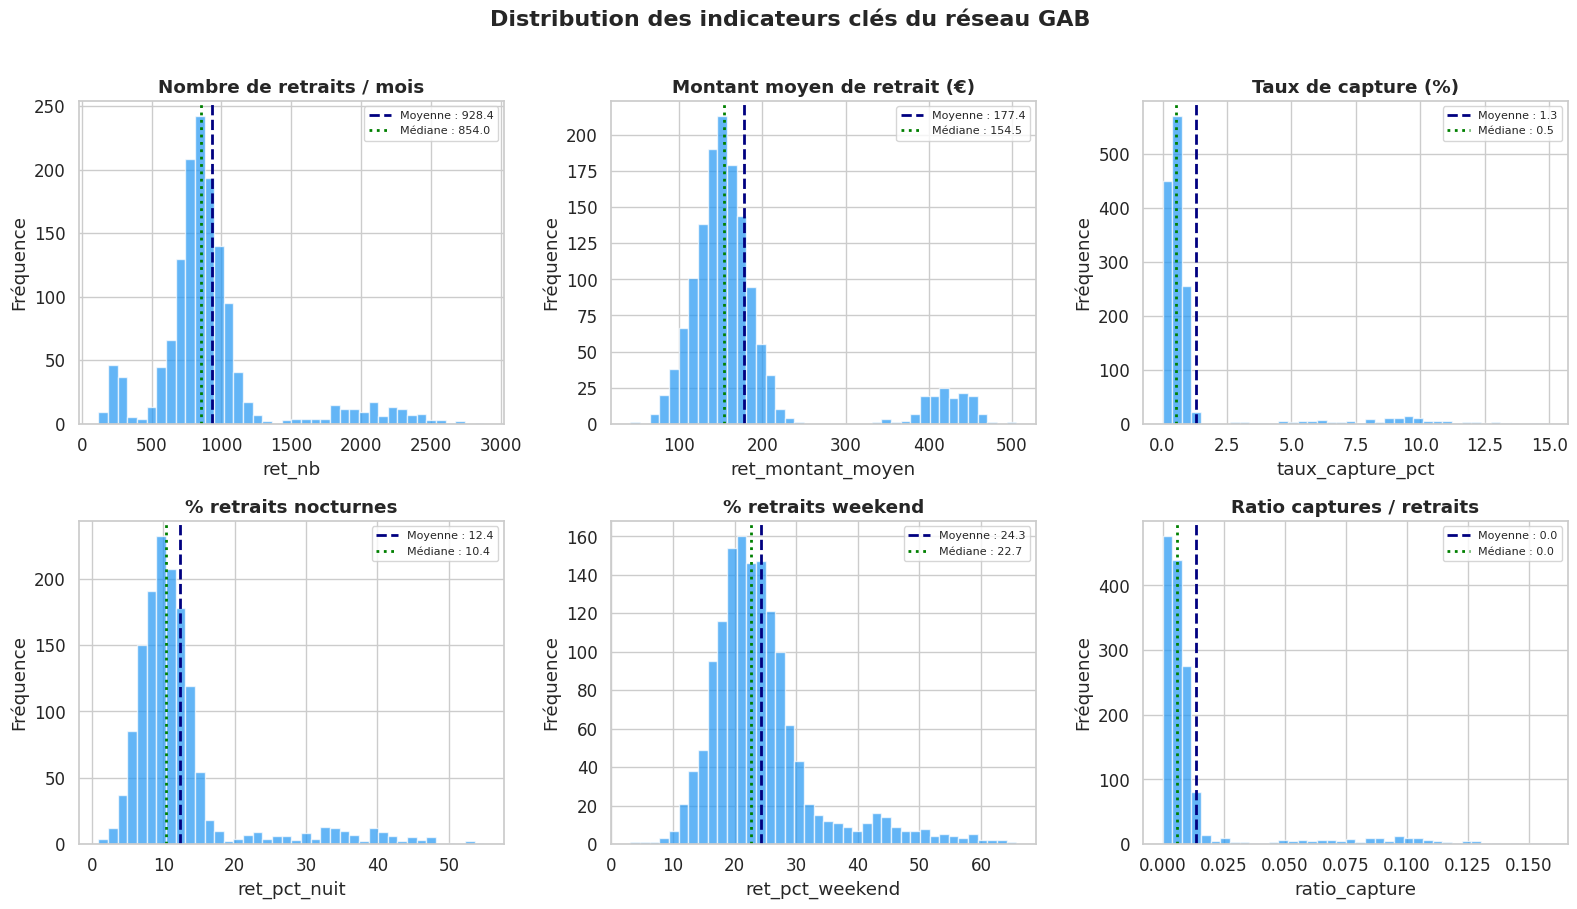

💡 La plupart des GAB se concentrent autour de valeurs stables → c'est le comportement NORMAL.


In [6]:
# ── 5.1 Distributions principales ────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Distribution des indicateurs clés du réseau GAB', fontsize=16, fontweight='bold', y=1.01)

variables = [
    ('ret_nb',           'Nombre de retraits / mois'),
    ('ret_montant_moyen','Montant moyen de retrait (€)'),
    ('taux_capture_pct', 'Taux de capture (%)'),
    ('ret_pct_nuit',     '% retraits nocturnes'),
    ('ret_pct_weekend',  '% retraits weekend'),
    ('ratio_capture',    'Ratio captures / retraits'),
]

for ax, (col, titre) in zip(axes.flatten(), variables):
    data_plot = df[col].dropna()
    ax.hist(data_plot, bins=40, color=COULEUR_NORMAL, alpha=0.7, edgecolor='white')
    ax.axvline(data_plot.mean(),   color='navy',  lw=2, ls='--', label=f'Moyenne : {data_plot.mean():.1f}')
    ax.axvline(data_plot.median(), color='green', lw=2, ls=':',  label=f'Médiane : {data_plot.median():.1f}')
    ax.set_title(titre, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Fréquence')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('distributions_gab.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 La plupart des GAB se concentrent autour de valeurs stables → c\'est le comportement NORMAL.')

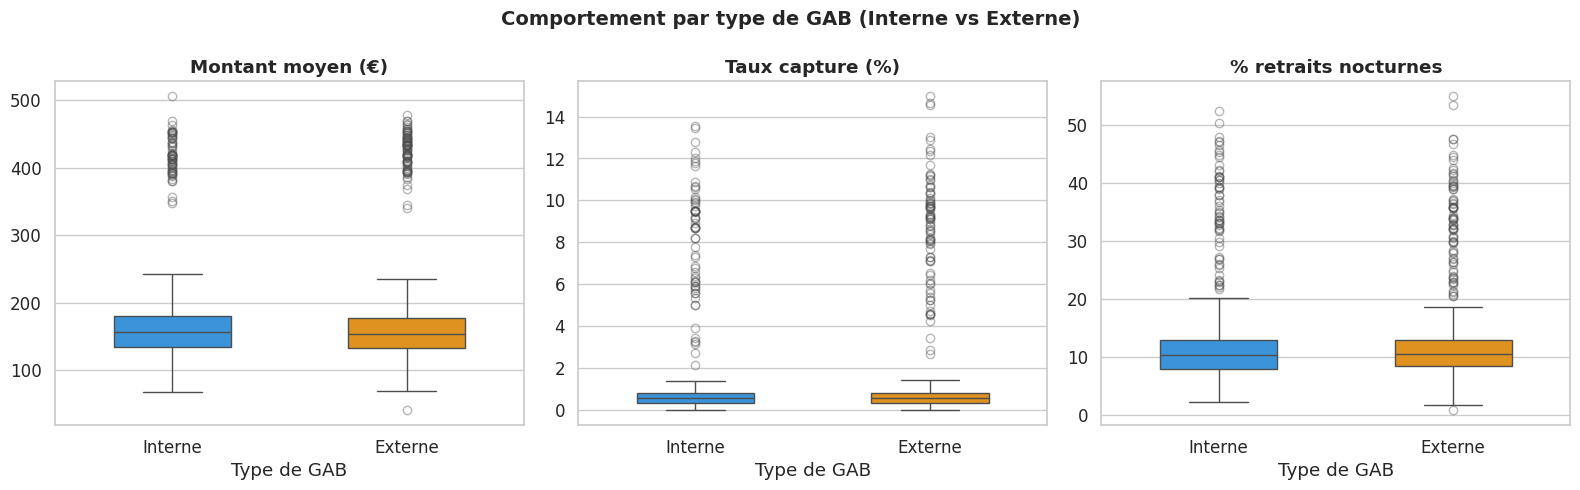

💡 Les GAB Internes (en agence) ont des profils différents des GAB Externes → à comparer séparément.


In [7]:
# ── 5.2 Boxplots par type GAB ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Comportement par type de GAB (Interne vs Externe)', fontsize=14, fontweight='bold')

metriques_box = [
    ('ret_montant_moyen', 'Montant moyen (€)'),
    ('taux_capture_pct',  'Taux capture (%)'),
    ('ret_pct_nuit',      '% retraits nocturnes'),
]

for ax, (col, titre) in zip(axes, metriques_box):
    sns.boxplot(data=df, x='type_gab_e_i', y=col, ax=ax,
                palette={'Interne': COULEUR_NORMAL, 'Externe': COULEUR_ACCENT},
                width=0.5, flierprops={'marker':'o','alpha':0.4})
    ax.set_title(titre, fontweight='bold')
    ax.set_xlabel('Type de GAB')
    ax.set_ylabel('')

plt.tight_layout()
plt.savefig('boxplots_type_gab.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Les GAB Internes (en agence) ont des profils différents des GAB Externes → à comparer séparément.')

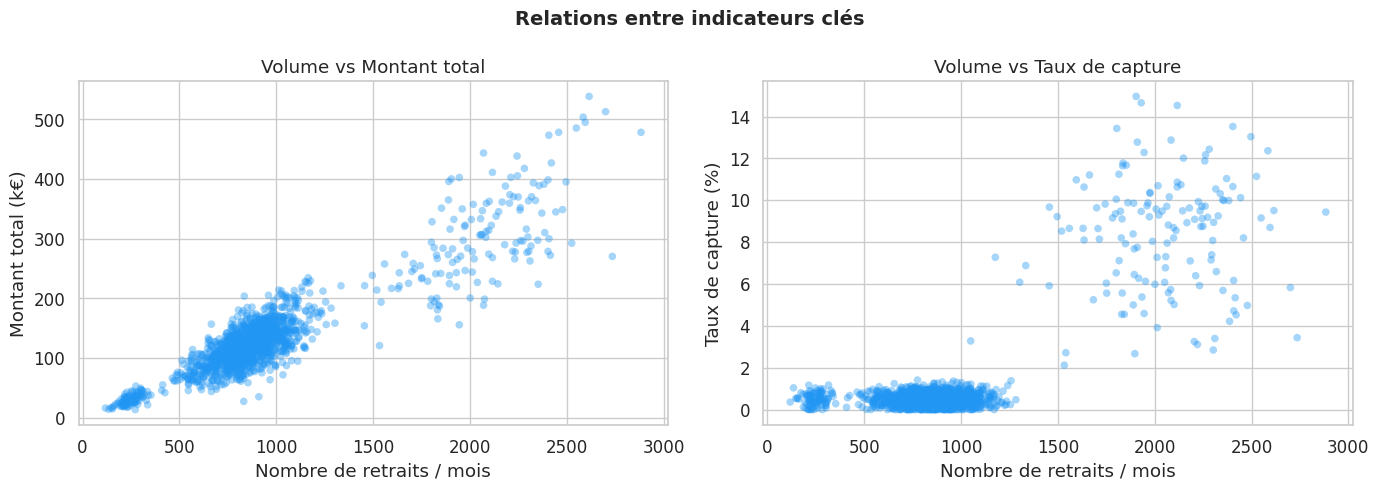

In [8]:
# ── 5.3 Scatter : volume vs montants ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Relations entre indicateurs clés', fontsize=14, fontweight='bold')

axes[0].scatter(df['ret_nb'], df['ret_montant_total']/1000,
                alpha=0.4, c=COULEUR_NORMAL, edgecolors='none', s=30)
axes[0].set_xlabel('Nombre de retraits / mois')
axes[0].set_ylabel('Montant total (k€)')
axes[0].set_title('Volume vs Montant total')

axes[1].scatter(df['ret_nb'], df['taux_capture_pct'],
                alpha=0.4, c=COULEUR_NORMAL, edgecolors='none', s=30)
axes[1].set_xlabel('Nombre de retraits / mois')
axes[1].set_ylabel('Taux de capture (%)')
axes[1].set_title('Volume vs Taux de capture')

plt.tight_layout()
plt.savefig('scatter_indicateurs.png', dpi=150, bbox_inches='tight')
plt.show()

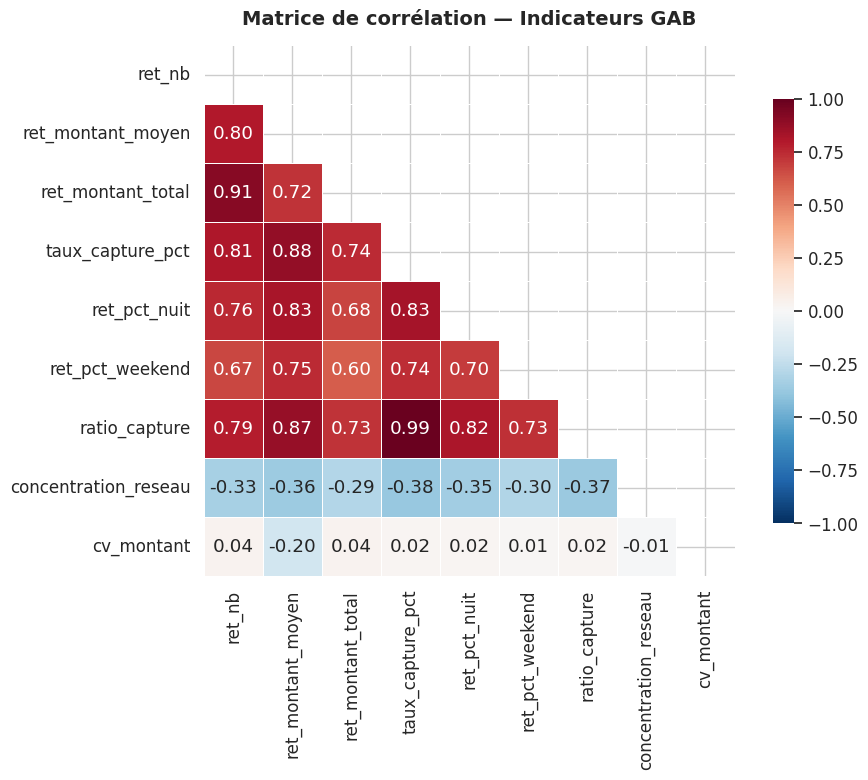

💡 Des corrélations fortes entre variables peuvent indiquer un comportement cohérent (normal) ou anormal.


In [9]:
# ── 5.4 Heatmap de corrélation ─────────────────────────────────────────────────
features_corr = ['ret_nb','ret_montant_moyen','ret_montant_total',
                 'taux_capture_pct','ret_pct_nuit','ret_pct_weekend',
                 'ratio_capture','concentration_reseau','cv_montant']

corr_matrix = df[features_corr].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Matrice de corrélation — Indicateurs GAB', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('heatmap_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Des corrélations fortes entre variables peuvent indiquer un comportement cohérent (normal) ou anormal.')

## 5bis. 🌍 Focus Réseaux Étrangers (JCB, Amex, Diners)

### Pourquoi surveiller les réseaux étrangers ?

Les cartes **JCB** (Japon), **Amex** et **Diners/Discovery** sont utilisées majoritairement par des **touristes étrangers**.  
Une activité anormalement élevée sur ces réseaux dans un GAB donné peut signaler :
- Un GAB situé dans une zone touristique à forte fréquentation étrangère *(contexte normal)*
- Une utilisation frauduleuse concentrée sur un seul automate *(signal d'alerte)*

La **cartographie géographique** permet de distinguer ces deux cas.


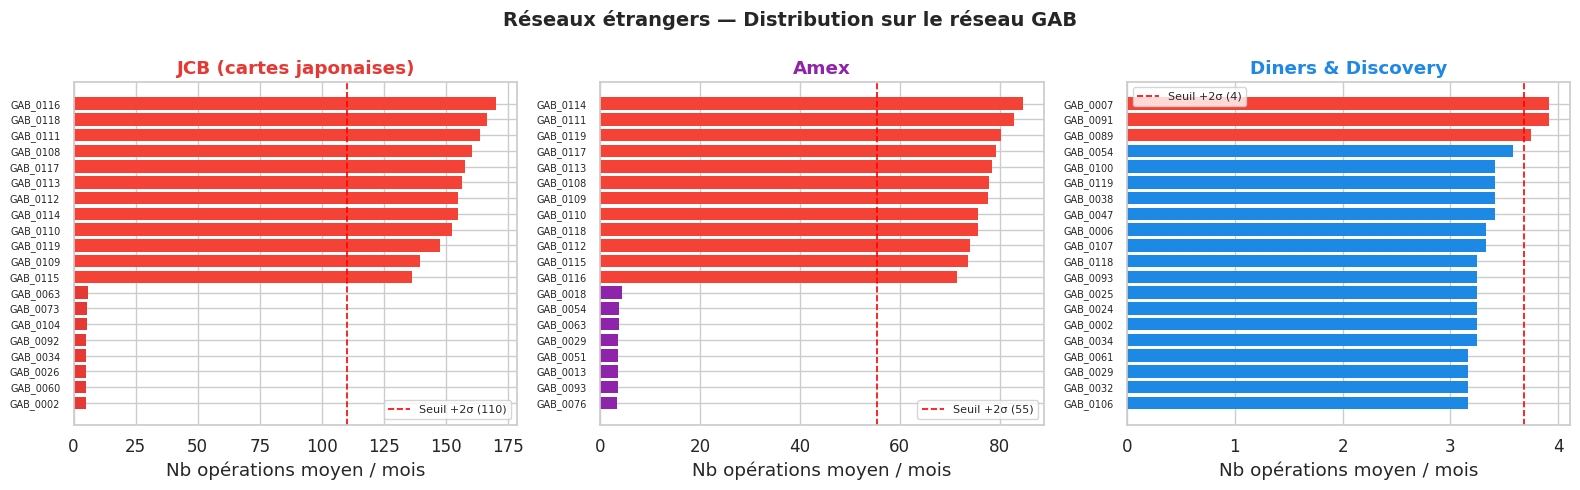

💡 Les barres rouges signalent les GAB dépassant le seuil +2σ pour ce réseau.


In [10]:
# ── 5bis.1 Part des réseaux étrangers par GAB ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Réseaux étrangers — Distribution sur le réseau GAB',
             fontsize=14, fontweight='bold')

reseaux_etrangers_plot = [
    ('nb_ope_reseau_jcb',                      'JCB (cartes japonaises)',   '#E53935'),
    ('nb_ope_reseau_amex',                     'Amex',                      '#8E24AA'),
    ('nb_ope_reseau_carte_diners_et_discovery','Diners & Discovery',        '#1E88E5'),
]

for ax, (col, label, color) in zip(axes, reseaux_etrangers_plot):
    if col not in df.columns:
        ax.set_visible(False)
        continue
    data = df.groupby('num_automate')[col].mean().sort_values(ascending=False)
    # Top 20 GAB
    top = data.head(20)
    couleurs = [COULEUR_ANOMALIE if v > data.mean() + 2*data.std() else color
                for v in top.values]
    ax.barh(range(len(top)), top.values, color=couleurs, edgecolor='none')
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(top.index, fontsize=7)
    ax.set_title(label, fontweight='bold', color=color)
    ax.set_xlabel('Nb opérations moyen / mois')
    ax.invert_yaxis()
    # Ligne de seuil d'alerte
    seuil = data.mean() + 2*data.std()
    ax.axvline(seuil, color='red', ls='--', lw=1.2, label=f'Seuil +2σ ({seuil:.0f})')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('reseaux_etrangers_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('💡 Les barres rouges signalent les GAB dépassant le seuil +2σ pour ce réseau.')


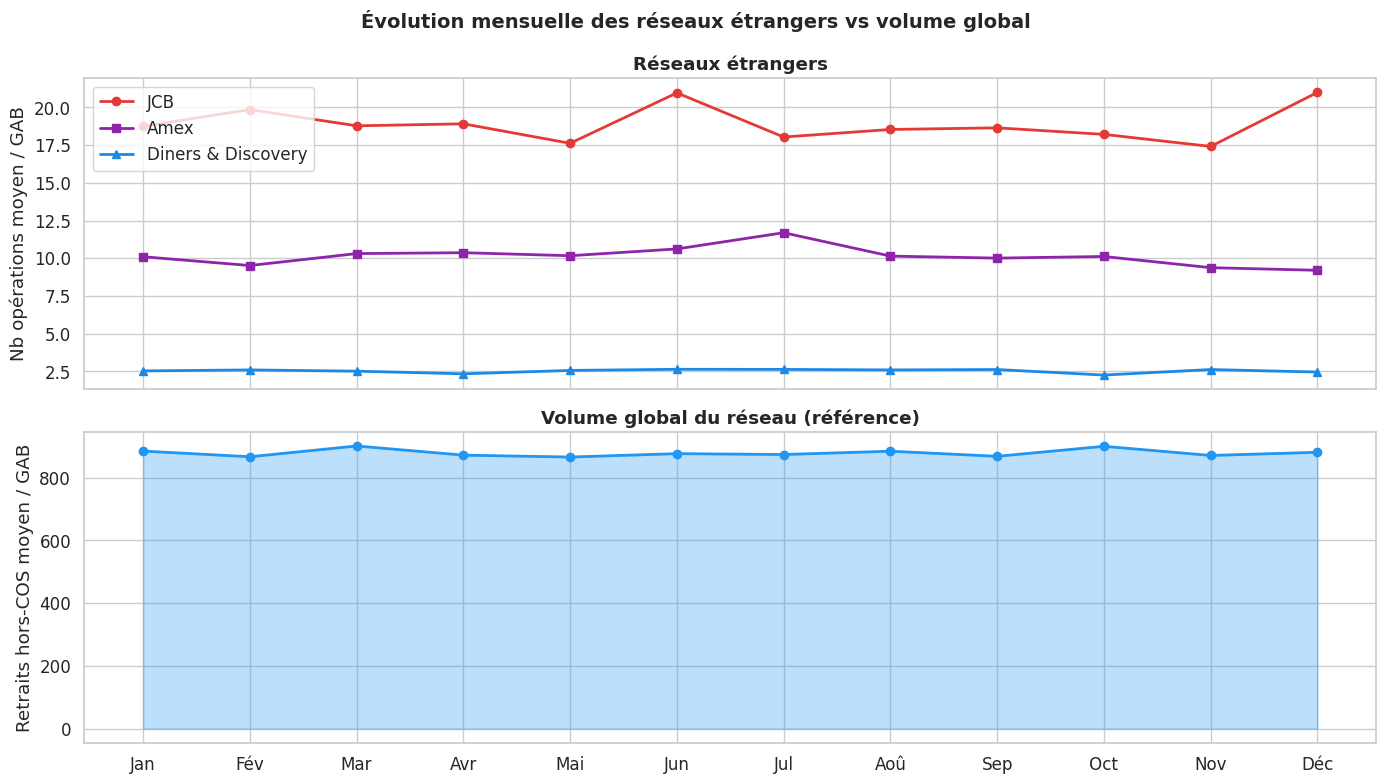

💡 Un pic de JCB en été sans hausse du volume global = signal potentiel.


In [11]:
# ── 5bis.2 Évolution temporelle des réseaux étrangers ────────────────────────
df_temp_etr = df.groupby('mois').agg(
    jcb_moyen   = ('nb_ope_reseau_jcb',                      'mean'),
    amex_moyen  = ('nb_ope_reseau_amex',                     'mean'),
    diners_moyen= ('nb_ope_reseau_carte_diners_et_discovery', 'mean'),
    ret_nb_moyen= ('ret_nb_horscos',                         'mean'),
).reset_index()

mois_labels = ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc']

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle('Évolution mensuelle des réseaux étrangers vs volume global',
             fontsize=14, fontweight='bold')

# Axe 1 : réseaux étrangers
ax1 = axes[0]
ax1.plot(df_temp_etr['mois'], df_temp_etr['jcb_moyen'],
         'o-', color='#E53935', lw=2, label='JCB')
ax1.plot(df_temp_etr['mois'], df_temp_etr['amex_moyen'],
         's-', color='#8E24AA', lw=2, label='Amex')
ax1.plot(df_temp_etr['mois'], df_temp_etr['diners_moyen'],
         '^-', color='#1E88E5', lw=2, label='Diners & Discovery')
ax1.set_ylabel('Nb opérations moyen / GAB')
ax1.set_title('Réseaux étrangers', fontweight='bold')
ax1.legend(loc='upper left')
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(mois_labels)

# Axe 2 : volume global
ax2 = axes[1]
ax2.fill_between(df_temp_etr['mois'], df_temp_etr['ret_nb_moyen'],
                 alpha=0.3, color=COULEUR_NORMAL)
ax2.plot(df_temp_etr['mois'], df_temp_etr['ret_nb_moyen'],
         'o-', color=COULEUR_NORMAL, lw=2, label='Volume retraits hors-COS')
ax2.set_ylabel('Retraits hors-COS moyen / GAB')
ax2.set_title('Volume global du réseau (référence)', fontweight='bold')
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels(mois_labels)

plt.tight_layout()
plt.savefig('reseaux_etrangers_temporel.png', dpi=150, bbox_inches='tight')
plt.show()

print('💡 Un pic de JCB en été sans hausse du volume global = signal potentiel.')


In [12]:
# ── 5bis.3 Carte géographique des réseaux étrangers ──────────────────────────
df_geo_etr = df.groupby('num_automate').agg(
    latitude          = ('latitude',                       'first'),
    longitude         = ('longitude',                      'first'),
    region            = ('region',                        'first') if 'region' in df.columns else ('latitude','first'),
    type_zone         = ('type_zone',                     'first') if 'type_zone' in df.columns else ('latitude','first'),
    jcb_moyen         = ('nb_ope_reseau_jcb',             'mean'),
    amex_moyen        = ('nb_ope_reseau_amex',            'mean'),
    diners_moyen      = ('nb_ope_reseau_carte_diners_et_discovery','mean'),
    ret_nb_moyen      = ('ret_nb_horscos',                'mean'),
    est_anomalie_flag = ('flag_atypique',                 'max'),
).reset_index()

df_geo_etr['nb_etranger_total'] = (df_geo_etr['jcb_moyen']
                                   + df_geo_etr['amex_moyen']
                                   + df_geo_etr['diners_moyen'])
df_geo_etr['statut'] = df_geo_etr['est_anomalie_flag'].map({0:'Normal',1:'Atypique'})

fig_etr = px.scatter_mapbox(
    df_geo_etr,
    lat='latitude', lon='longitude',
    color='nb_etranger_total',
    size='nb_etranger_total',
    size_max=25,
    color_continuous_scale=['#E8F5E9','#FFF9C4','#FFCCBC','#B71C1C'],
    hover_name='num_automate',
    hover_data={
        'jcb_moyen':    ':.1f',
        'amex_moyen':   ':.1f',
        'diners_moyen': ':.1f',
        'ret_nb_moyen': ':.0f',
        'statut':       True,
        'nb_etranger_total': False,
        'latitude': False, 'longitude': False,
    },
    mapbox_style='carto-positron',
    zoom=4, center={'lat': 46.5, 'lon': 2.5},
    title='🌍 Intensité des réseaux étrangers (JCB + Amex + Diners) par GAB',
    height=550,
)
fig_etr.update_layout(margin={'r':0,'t':40,'l':0,'b':0},
                      coloraxis_colorbar_title='Nb opérations<br>étrangères / mois')
fig_etr.show()
print('💡 Les points les plus foncés = forte activité sur réseaux étrangers.')
print('   Comparer avec la localisation (zone touristique ?) pour interpréter.')


💡 Les points les plus foncés = forte activité sur réseaux étrangers.
   Comparer avec la localisation (zone touristique ?) pour interpréter.


## 6. 📅 Analyse Temporelle

### Le comportement des GAB évolue-t-il dans le temps ?

La **saisonnalité** est un facteur clé : une hausse d'activité en décembre est normale.  
Ce qui n'est **pas** normal : une hausse isolée sur un seul automate, hors saison.

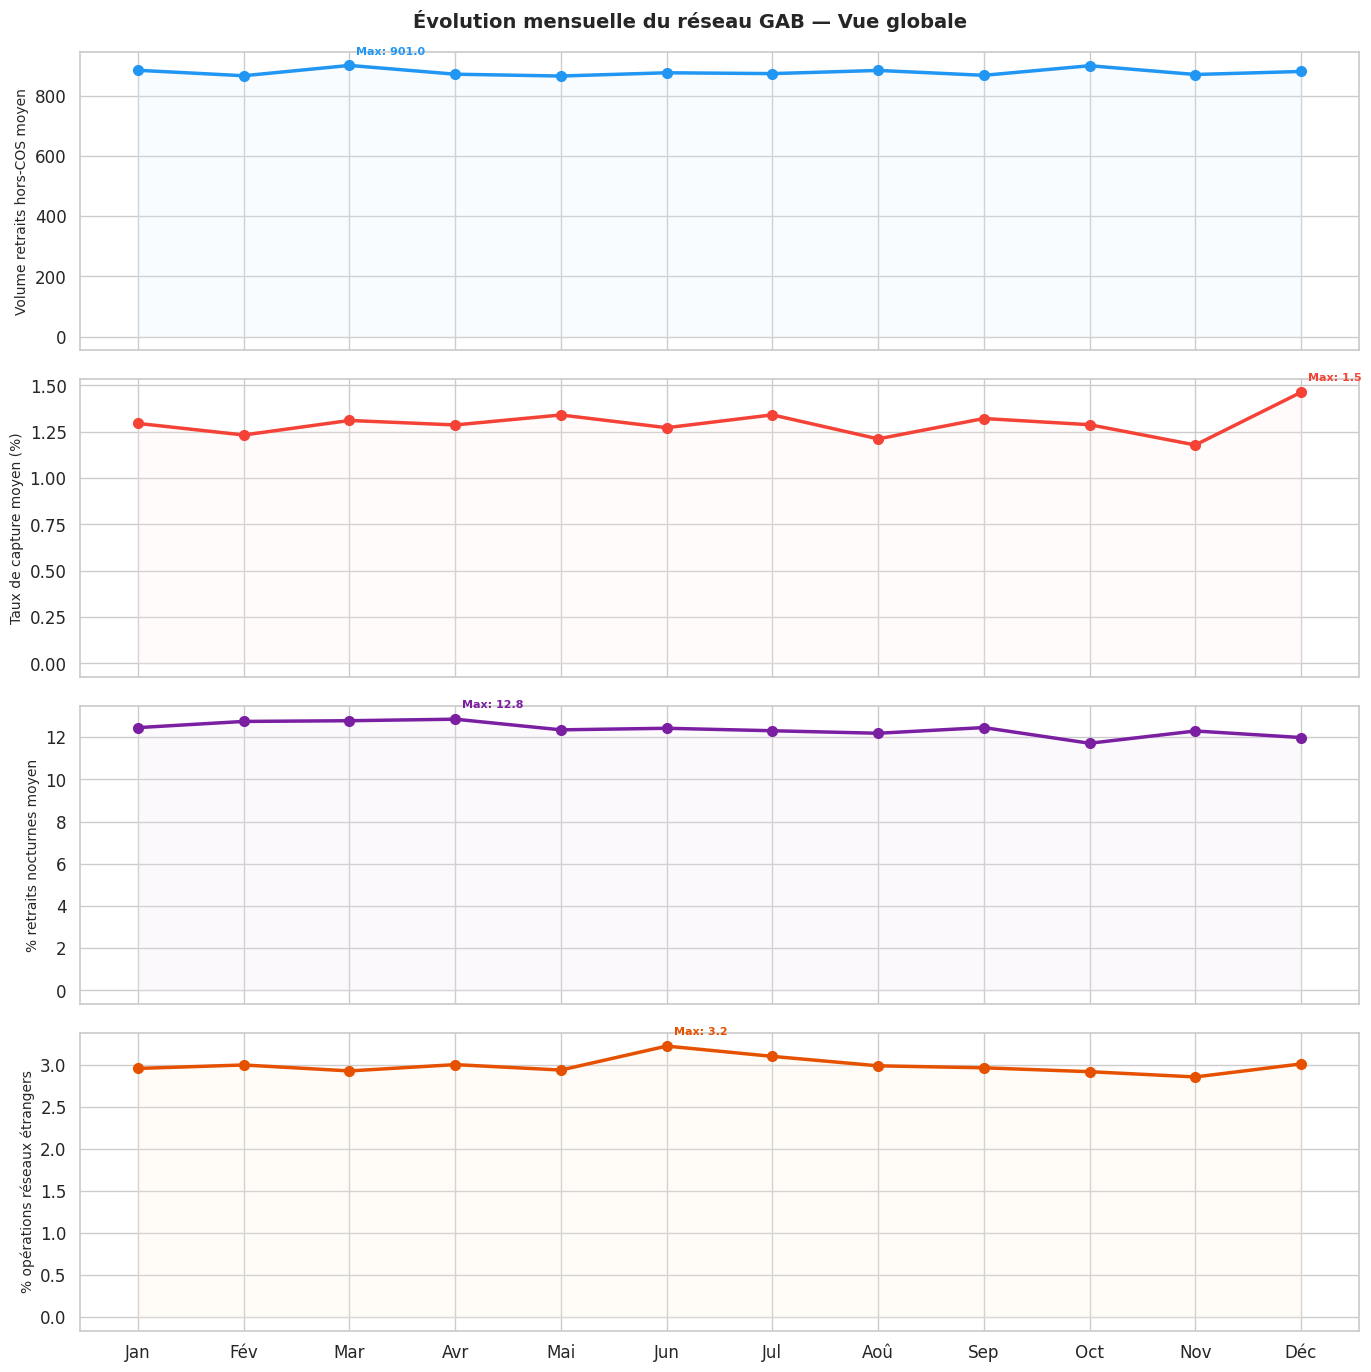


📅 Nombre de GAB atypiques par mois :
    Jan : ██████ 12
    Fév : ██████ 12
    Mar : ██████ 12
    Avr : ██████ 12
    Mai : ██████ 12
    Jun : ██████ 12
    Jul : ██████ 12
    Aoû : ██████ 12
    Sep : ██████ 12
    Oct : ██████ 12
    Nov : ██████ 12
    Déc : ██████ 12


In [13]:
# ── 6.1 Évolution mensuelle du réseau — tendances globales ───────────────────
df_temps = df.groupby(['annee','mois']).agg(
    ret_nb_moyen        = ('ret_nb_horscos',    'mean'),
    montant_moyen       = ('ret_montant_moyen', 'mean'),
    taux_capture_moyen  = ('taux_capture_pct',  'mean'),
    pct_nuit_moyen      = ('ret_pct_nuit',      'mean'),
    pct_etranger_moyen  = ('pct_reseaux_etrangers','mean'),
    nb_atypiques        = ('flag_atypique',     'sum'),
).reset_index()

df_temps['periode'] = pd.to_datetime(
    df_temps['annee'].astype(str) + '-' + df_temps['mois'].astype(str).str.zfill(2)
)
df_temps = df_temps.sort_values('periode')

mois_labels = ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc']

fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)
fig.suptitle('Évolution mensuelle du réseau GAB — Vue globale',
             fontsize=14, fontweight='bold')

series_plot = [
    (axes[0], 'ret_nb_moyen',       'Volume retraits hors-COS moyen',  COULEUR_NORMAL,  '#E3F2FD'),
    (axes[1], 'taux_capture_moyen', 'Taux de capture moyen (%)',        COULEUR_ANOMALIE,'#FFEBEE'),
    (axes[2], 'pct_nuit_moyen',     '% retraits nocturnes moyen',       '#7B1FA2',       '#F3E5F5'),
    (axes[3], 'pct_etranger_moyen', '% opérations réseaux étrangers',   '#E65100',       '#FFF3E0'),
]

for ax, col, label, color, fill_color in series_plot:
    ax.fill_between(df_temps['mois'], df_temps[col], alpha=0.2, color=fill_color)
    ax.plot(df_temps['mois'], df_temps[col], 'o-', color=color, lw=2.5, ms=7)
    ax.set_ylabel(label, fontsize=10)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(mois_labels)
    # Annotation du max
    idx_max = df_temps[col].idxmax()
    ax.annotate(f'Max: {df_temps[col].max():.1f}',
                xy=(df_temps.loc[idx_max,'mois'], df_temps.loc[idx_max,col]),
                xytext=(5, 8), textcoords='offset points',
                fontsize=8, color=color, fontweight='bold')

plt.tight_layout()
plt.savefig('evolution_temporelle.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 6.2 Identification des mois atypiques ────────────────────────────────────
print('\n📅 Nombre de GAB atypiques par mois :')
for _, row in df_temps.iterrows():
    barre = '█' * int(row['nb_atypiques'] / 2)
    print(f'   {mois_labels[int(row["mois"])-1]:>4} : {barre} {int(row["nb_atypiques"])}')


## 7. 🗺️ Analyse Géographique

La localisation d'un GAB influence fortement son comportement.  
Un GAB en centre-ville traite naturellement plus de retraits qu'un GAB rural.  
La carte nous permet de **contextualiser** chaque anomalie géographiquement.

In [15]:
# ── 7.1 Carte interactive — contexte géographique métier ─────────────────────

df_geo = df.groupby('num_automate').agg(
    longitude          = ('longitude',          'first'),
    latitude           = ('latitude',           'first'),
    ret_nb_moyen       = ('ret_nb_horscos',     'mean'),
    taux_capture_moyen = ('taux_capture_pct',   'mean'),
    type_gab           = ('type_gab_e_i',       'first'),
    type_zone          = ('type_zone',          'first') if 'type_zone' in df.columns else ('latitude','first'),
    region             = ('region',             'first') if 'region' in df.columns else ('latitude','first'),
    pct_etranger       = ('pct_reseaux_etrangers','mean') if 'pct_reseaux_etrangers' in df.columns else ('ret_nb','mean'),
    flag_atypique_max  = ('flag_atypique',      'max'),
    nb_mois_atypiques  = ('flag_atypique',      'sum'),
).reset_index()

df_geo['statut'] = df_geo['flag_atypique_max'].map({
    0:'Normal',
    1:'Atypique'
})

df_geo['contexte'] = df_geo['type_zone'].map(
    {
        'insulaire':'Zone insulaire (faible affluence normale)',
        'urbain_dense':'Zone urbaine dense',
        'urbain':'Zone urbaine'
    }
).fillna('Non renseigné')


# ── Carte corrigée ─────────────────────────────────────────────

fig_map = px.scatter_mapbox(
    df_geo,
    lat='latitude',
    lon='longitude',
    color='statut',
    color_discrete_map={
        'Normal': COULEUR_NORMAL,
        'Atypique': COULEUR_ANOMALIE
    },
    size='ret_nb_moyen',
    size_max=20,
    hover_name='num_automate',
    hover_data={
        'ret_nb_moyen':':.0f',
        'taux_capture_moyen':':.2f',
        'nb_mois_atypiques':True,
        'contexte':True,
        'region':True,
        'statut':False,
        'latitude':False,
        'longitude':False,
    },
    mapbox_style='carto-positron',
    zoom=4,
    center={'lat':46.5,'lon':2.5},
    title='🗺️ Carte du réseau GAB — Anomalies et contexte géographique',
    height=580
)

fig_map.update_layout(
    margin={'r':0,'t':40,'l':0,'b':0},
    legend_title_text='Statut'
)

fig_map.show()


print("💡 Les GAB insulaires (Saint-Martin, Guadeloupe) ont un faible volume")
print("   de retraits par nature — ce n'est PAS une anomalie.")

print("\n📊 Répartition par zone :")
print(df_geo.groupby('type_zone')['statut'].value_counts().to_string())

💡 Les GAB insulaires (Saint-Martin, Guadeloupe) ont un faible volume
   de retraits par nature — ce n'est PAS une anomalie.

📊 Répartition par zone :
type_zone     statut  
insulaire     Normal       8
urbain        Normal      69
              Atypique     8
urbain_dense  Normal      31
              Atypique     4


## 8. 🤖 Modélisation — Détection d'Anomalies

### Pourquoi l'Isolation Forest ?

| Modèle | Principe | Adapté ici ? |
|---|---|---|
| **Isolation Forest** | Isole les points rares par partitions aléatoires | ✅ Oui — rapide, robuste, interprétable |
| Local Outlier Factor | Densité locale vs voisins | ⚠️ Lent sur grands datasets |
| One-Class SVM | Frontière autour des normaux | ⚠️ Difficile à paramétrer |
| Seuils statistiques | z-score, IQR | ⚠️ Univarié, ne capte pas les interactions |

**Isolation Forest** est notre choix car :
- Il gère bien les **données multivariées** (50+ colonnes)
- Il est **rapide** sur de grands volumes
- Il produit un **score d'anomalie** continu (pas seulement un label)
- Il est **intuitif** : un point difficile à isoler = normal, facile à isoler = anormal

In [16]:
# ── 8.1 Sélection des features pour le modèle ─────────────────────────────────
# On utilise ret_nb_horscos (hors COS) pour ne pas biaiser le modèle
# On inclut les réseaux étrangers comme signal spécifique
# On exclut les zones à faible affluence naturelle du modèle principal

FEATURES_MODELE = [
    # Volume et montants (hors COS)
    'ret_nb_horscos',
    'ret_montant_moyen',
    'ret_montant_max',
    'ret_montant_stddev',
    'ret_montant_total',
    # Capture hors COS
    'taux_capture_pct',
    'ratio_capture',
    # Temporel
    'ret_pct_nuit',
    'ret_pct_weekend',
    'score_horaires_atypiques',
    # Features enrichies
    'intensite_retrait_ajustee',   # ajustée pour contexte géographique
    'concentration_reseau',
    'cv_montant',
    # Réseaux étrangers (signal spécifique)
    'pct_reseaux_etrangers',
    'nb_ope_reseaux_etrangers',
    # Réseaux principaux
    'nb_ope_reseau_cb',
    'nb_ope_reseau_visa',
    'nb_ope_reseau_mastercard',
    'nb_ope_reseau_interne',
    'nb_ope_reseau_jcb',
    'nb_ope_reseau_amex',
    'nb_ope_reseau_carte_diners_et_discovery',
]

# Filtrer les features disponibles dans le dataset
FEATURES_MODELE = [f for f in FEATURES_MODELE if f in df.columns]

X = df[FEATURES_MODELE].fillna(0)

# ── 8.2 Normalisation ─────────────────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'✅ Matrice features : {X_scaled.shape[0]} lignes × {X_scaled.shape[1]} features')
print(f'\nFeatures utilisées :')
for i, f in enumerate(FEATURES_MODELE, 1):
    print(f'   {i:2d}. {f}')


✅ Matrice features : 1440 lignes × 22 features

Features utilisées :
    1. ret_nb_horscos
    2. ret_montant_moyen
    3. ret_montant_max
    4. ret_montant_stddev
    5. ret_montant_total
    6. taux_capture_pct
    7. ratio_capture
    8. ret_pct_nuit
    9. ret_pct_weekend
   10. score_horaires_atypiques
   11. intensite_retrait_ajustee
   12. concentration_reseau
   13. cv_montant
   14. pct_reseaux_etrangers
   15. nb_ope_reseaux_etrangers
   16. nb_ope_reseau_cb
   17. nb_ope_reseau_visa
   18. nb_ope_reseau_mastercard
   19. nb_ope_reseau_interne
   20. nb_ope_reseau_jcb
   21. nb_ope_reseau_amex
   22. nb_ope_reseau_carte_diners_et_discovery


In [17]:
# ── 8.3 Entraînement Isolation Forest ─────────────────────────────────────────
# contamination = proportion estimée d'anomalies dans le réseau (~5%)
modele = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42,
    n_jobs=-1
)

df['score_anomalie'] = modele.fit_predict(X_scaled)  # -1 = anomalie, +1 = normal
df['score_if']       = modele.score_samples(X_scaled)  # plus bas = plus anormal

# Normalisation du score en [0, 1] pour lisibilité métier
score_min, score_max = df['score_if'].min(), df['score_if'].max()
df['score_risque'] = 1 - (df['score_if'] - score_min) / (score_max - score_min)
# score_risque proche de 1 = très anormal

df['est_anomalie'] = (df['score_anomalie'] == -1).astype(int)

n_anomalies = df['est_anomalie'].sum()
print(f'🚨 GAB atypiques détectés : {n_anomalies} / {len(df)} ({n_anomalies/len(df)*100:.1f}%)')

🚨 GAB atypiques détectés : 72 / 1440 (5.0%)


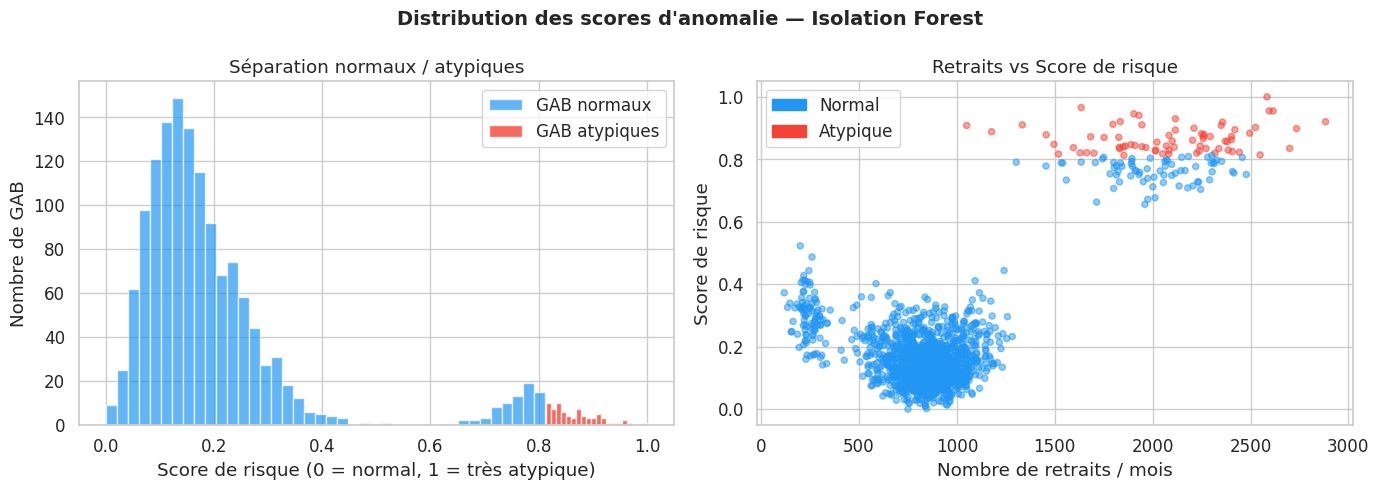

In [18]:
# ── 8.4 Visualisation du score d'anomalie ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribution des scores d\'anomalie — Isolation Forest', fontsize=14, fontweight='bold')

# Histogramme des scores
ax = axes[0]
ax.hist(df[df['est_anomalie']==0]['score_risque'], bins=40,
        color=COULEUR_NORMAL, alpha=0.7, label='GAB normaux')
ax.hist(df[df['est_anomalie']==1]['score_risque'], bins=20,
        color=COULEUR_ANOMALIE, alpha=0.8, label='GAB atypiques')
ax.set_xlabel('Score de risque (0 = normal, 1 = très atypique)')
ax.set_ylabel('Nombre de GAB')
ax.set_title('Séparation normaux / atypiques')
ax.legend()

# Scatter retraits vs score risque
ax2 = axes[1]
couleurs = [COULEUR_ANOMALIE if a==1 else COULEUR_NORMAL for a in df['est_anomalie']]
ax2.scatter(df['ret_nb'], df['score_risque'], c=couleurs, alpha=0.5, s=20)
ax2.set_xlabel('Nombre de retraits / mois')
ax2.set_ylabel('Score de risque')
ax2.set_title('Retraits vs Score de risque')
patch_n = mpatches.Patch(color=COULEUR_NORMAL,   label='Normal')
patch_a = mpatches.Patch(color=COULEUR_ANOMALIE, label='Atypique')
ax2.legend(handles=[patch_n, patch_a])

plt.tight_layout()
plt.savefig('scores_anomalie.png', dpi=150, bbox_inches='tight')
plt.show()

## 8bis. 🔬 Clustering — Familles de comportements GAB

### Comparer chaque GAB à ses pairs, pas à l'ensemble du réseau

Un GAB rural et un GAB de centre commercial ne sont pas "normaux" de la même façon.  
Le clustering regroupe les GAB par **profil similaire**, permettant une comparaison plus équitable :  
un GAB est atypique **au sein de sa famille**, pas dans l'absolu.


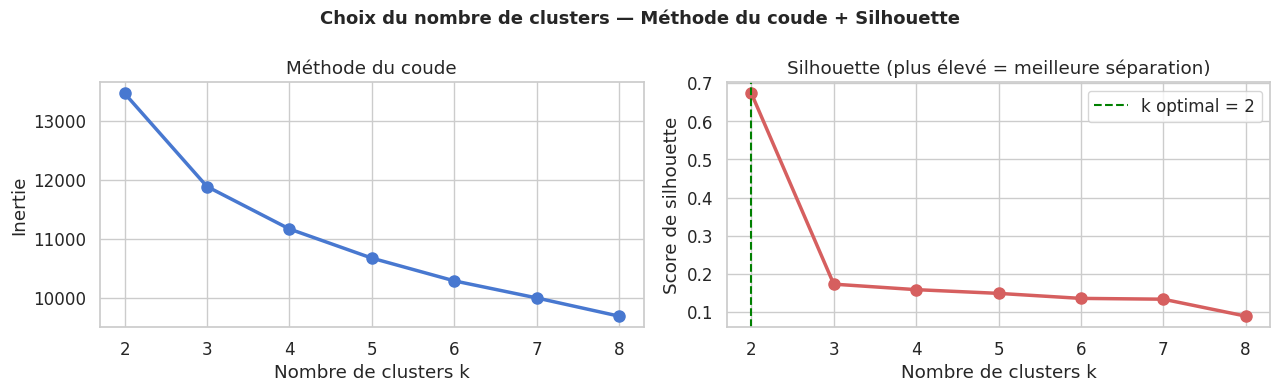

✅ k optimal : 2 clusters (silhouette = 0.673)


In [19]:
# ── 8bis.1 Choix du nombre de clusters (méthode du coude + silhouette) ────────
inertias, sil_scores = [], []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Choix du nombre de clusters — Méthode du coude + Silhouette',
             fontsize=13, fontweight='bold')

axes[0].plot(K_range, inertias, 'bo-', lw=2.5, ms=8)
axes[0].set_xlabel('Nombre de clusters k')
axes[0].set_ylabel('Inertie')
axes[0].set_title('Méthode du coude')
axes[0].set_xticks(list(K_range))

axes[1].plot(K_range, sil_scores, 'ro-', lw=2.5, ms=8)
axes[1].set_xlabel('Nombre de clusters k')
axes[1].set_ylabel('Score de silhouette')
axes[1].set_title('Silhouette (plus élevé = meilleure séparation)')
axes[1].set_xticks(list(K_range))
k_opt = list(K_range)[sil_scores.index(max(sil_scores))]
axes[1].axvline(k_opt, color='green', ls='--', lw=1.5,
                label=f'k optimal = {k_opt}')
axes[1].legend()

plt.tight_layout()
plt.savefig('clustering_choix_k.png', dpi=150, bbox_inches='tight')
plt.show()

K_FINAL = k_opt
print(f'✅ k optimal : {K_FINAL} clusters (silhouette = {max(sil_scores):.3f})')


In [20]:
# ── 8bis.2 Entraînement KMeans et nommage des clusters ───────────────────────
km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
df['cluster'] = km_final.fit_predict(X_scaled)

# Profil moyen par cluster
feat_profil = ['ret_nb_horscos','ret_montant_moyen','taux_capture_pct',
               'ret_pct_nuit','ret_pct_weekend','pct_reseaux_etrangers',
               'intensite_retrait_ajustee','est_anomalie']
feat_profil = [f for f in feat_profil if f in df.columns]

profil = df.groupby('cluster')[feat_profil].mean().round(2)

# Nommage heuristique basé sur le profil dominant
def nommer_cluster(cid, row):
    if 'est_anomalie' in row.index and row['est_anomalie'] > 0.20:
        return f'🔴 C{cid} — Atypiques à risque élevé'
    if 'taux_capture_pct' in row.index and row['taux_capture_pct'] > 2.0:
        return f'🃏 C{cid} — Captures fréquentes'
    if 'pct_reseaux_etrangers' in row.index and row['pct_reseaux_etrangers'] > 5:
        return f'🌍 C{cid} — Fort trafic étranger'
    if 'ret_pct_nuit' in row.index and row['ret_pct_nuit'] > 18:
        return f'🌙 C{cid} — Activité nocturne'
    if 'ret_nb_horscos' in row.index and row['ret_nb_horscos'] > 900:
        return f'🏙️ C{cid} — Fort volume (urbain)'
    if 'ret_nb_horscos' in row.index and row['ret_nb_horscos'] < 300:
        return f'🏝️ C{cid} — Faible volume (rural/insulaire)'
    return f'🟢 C{cid} — Comportement standard'

NOMS_CLUSTERS = {cid: nommer_cluster(cid, profil.iloc[cid])
                 for cid in range(K_FINAL)}
df['cluster_nom'] = df['cluster'].map(NOMS_CLUSTERS)

print('📊 Profil moyen par cluster :')
display(profil.rename(index=NOMS_CLUSTERS).style
    .background_gradient(cmap='YlOrRd', subset=feat_profil[:-1])
    .format('{:.2f}'))

print('\n📋 Répartition :')
dist = df.groupby(['cluster','cluster_nom']).agg(
    nb_obs=('num_automate','count'),
    pct_anom=('est_anomalie','mean')
).reset_index()
dist['pct_anom'] = (dist['pct_anom']*100).round(1)
dist.columns = ['Cluster','Nom','Nb obs.','% Atypiques']
print(dist.to_string(index=False))


📊 Profil moyen par cluster :


,ret_nb_horscos,ret_montant_moyen,taux_capture_pct,ret_pct_nuit,ret_pct_weekend,pct_reseaux_etrangers,intensite_retrait_ajustee,est_anomalie
cluster,,,,,,,,
🟢 C0 — Comportement standard,754.70,150.25,0.51,9.99,21.99,1.00,25.88,0.00
🔴 C1 — Atypiques à risque élevé,1994.34,421.45,8.39,33.84,44.76,20.92,66.48,0.50



📋 Répartition :
 Cluster                             Nom  Nb obs.  % Atypiques
       0    🟢 C0 — Comportement standard     1296          0.0
       1 🔴 C1 — Atypiques à risque élevé      144         50.0


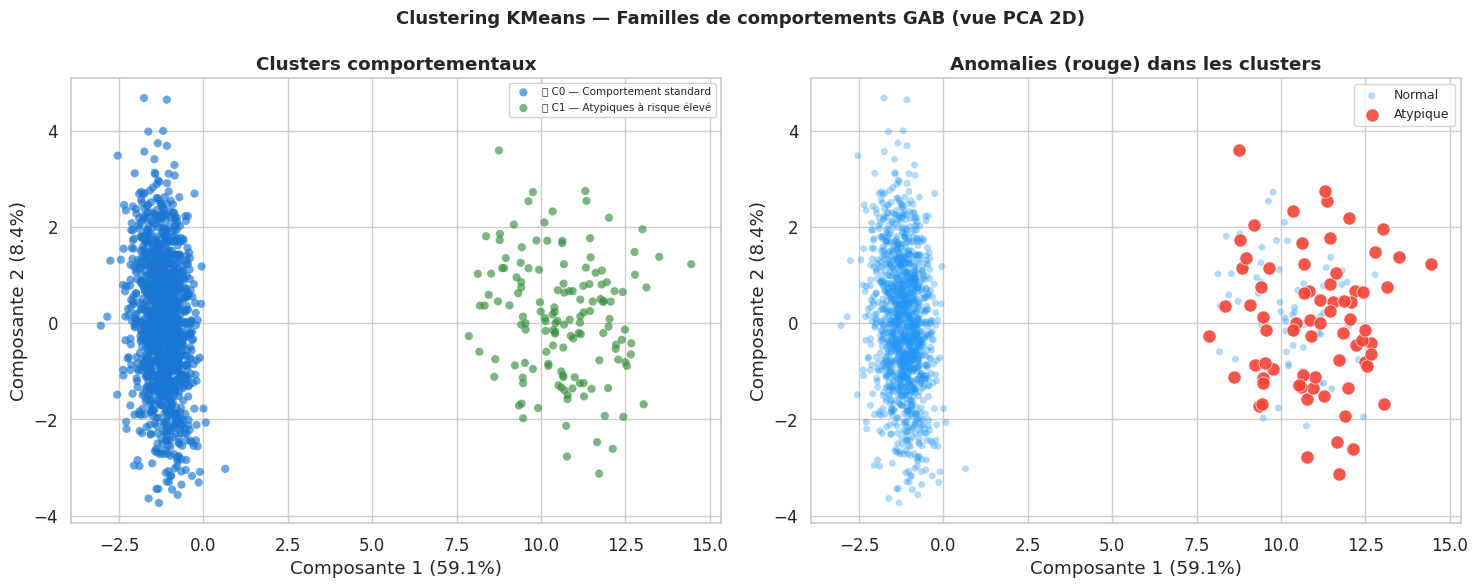

💡 Les 2 composantes PCA expliquent 67.4% de la variance totale.


In [21]:
# ── 8bis.3 Visualisation des clusters en 2D (PCA) ────────────────────────────
pca_clust = PCA(n_components=2, random_state=42)
Xp = pca_clust.fit_transform(X_scaled)
df['_pca1'], df['_pca2'] = Xp[:, 0], Xp[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Clustering KMeans — Familles de comportements GAB (vue PCA 2D)',
             fontsize=13, fontweight='bold')

# Gauche : clusters colorés
ax = axes[0]
for cid in sorted(df['cluster'].unique()):
    mask = df['cluster'] == cid
    color = PALETTE_CLUSTERS[cid % len(PALETTE_CLUSTERS)]
    ax.scatter(df.loc[mask,'_pca1'], df.loc[mask,'_pca2'],
               c=color, label=NOMS_CLUSTERS[cid],
               alpha=0.65, s=35, edgecolors='none')
ax.set_title('Clusters comportementaux', fontweight='bold')
ax.legend(loc='best', fontsize=7.5, framealpha=0.9)
ax.set_xlabel(f'Composante 1 ({pca_clust.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'Composante 2 ({pca_clust.explained_variance_ratio_[1]*100:.1f}%)')

# Droite : anomalies dans les clusters
ax2 = axes[1]
for label, mask, color, size, alpha in [
    ('Normal',   df['est_anomalie']==0, COULEUR_NORMAL,   25, 0.35),
    ('Atypique', df['est_anomalie']==1, COULEUR_ANOMALIE, 90, 0.90),
]:
    ax2.scatter(df.loc[mask,'_pca1'], df.loc[mask,'_pca2'],
                c=color, label=label, s=size, alpha=alpha,
                edgecolors='white' if size>40 else 'none', lw=0.5)
ax2.set_title('Anomalies (rouge) dans les clusters', fontweight='bold')
ax2.legend(fontsize=9)
ax2.set_xlabel(f'Composante 1 ({pca_clust.explained_variance_ratio_[0]*100:.1f}%)')
ax2.set_ylabel(f'Composante 2 ({pca_clust.explained_variance_ratio_[1]*100:.1f}%)')

plt.tight_layout()
plt.savefig('clustering_pca.png', dpi=150, bbox_inches='tight')
plt.show()

exp_var = (pca_clust.explained_variance_ratio_[:2].sum()*100)
print(f'💡 Les 2 composantes PCA expliquent {exp_var:.1f}% de la variance totale.')


## 9. 🔎 Explication des Anomalies Détectées

### Pourquoi ces GAB sont-ils atypiques ?

C'est **la partie la plus importante** pour convaincre les experts métier.  
Chaque anomalie doit être **expliquée en langage métier**.

In [22]:
# ── 9.1 Top 10 GAB les plus atypiques ─────────────────────────────────────────
top_anomalies = df[df['est_anomalie']==1].nlargest(10, 'score_risque')[
    ['num_automate','score_risque','ret_nb','ret_montant_moyen',
     'taux_capture_pct','ret_pct_nuit','ret_pct_weekend','type_gab_e_i']
].reset_index(drop=True)

top_anomalies.index += 1
top_anomalies.columns = ['Automate','Score risque','Nb retraits',
                          'Montant moyen (€)','Taux capture (%)','% Nuit','% Weekend','Type']

# Formatage
styled = top_anomalies.style \
    .background_gradient(subset=['Score risque'], cmap='Reds') \
    .background_gradient(subset=['Taux capture (%)'], cmap='Oranges') \
    .format({'Score risque': '{:.3f}', 'Taux capture (%)': '{:.2f}',
             'Montant moyen (€)': '{:.0f}', '% Nuit': '{:.1f}', '% Weekend': '{:.1f}'})

print('🚨 TOP 10 des GAB les plus atypiques :')
display(styled)

🚨 TOP 10 des GAB les plus atypiques :


,Automate,Score risque,Nb retraits,Montant moyen (€),Taux capture (%),% Nuit,% Weekend,Type
1,GAB_0119,1.000,2584,462,12.37,41.7,49.6,Externe
2,GAB_0114,0.966,1635,454,10.63,23.2,34.4,Interne
3,GAB_0114,0.955,2595,350,8.70,41.1,31.4,Interne
4,GAB_0111,0.955,2615,453,9.51,47.3,47.2,Interne
5,GAB_0118,0.946,1904,431,14.96,22.4,28.7,Externe
6,GAB_0112,0.941,1930,418,14.66,35.7,59.3,Externe
7,GAB_0117,0.930,2116,392,10.87,39.3,50.2,Interne
8,GAB_0110,0.921,1834,406,11.65,50.4,50.0,Interne
9,GAB_0113,0.920,2883,452,9.44,25.9,57.2,Interne
10,GAB_0111,0.919,2357,451,9.99,20.5,54.9,Externe


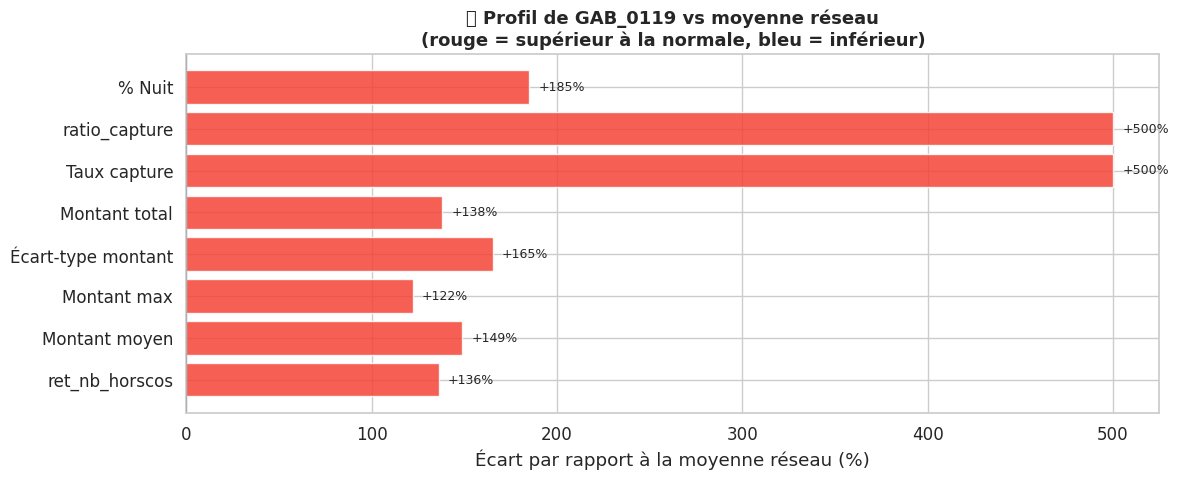


📋 Interprétation métier de GAB_0119 :
   → Taux de capture : 12.4%  (réseau : 0.9%)
   → Montant moyen   : 462€  (réseau : 165€)
   → Activité nocturne : 41.7%  (réseau : 11.2%)


In [23]:
# ── 9.2 Profil d'un GAB atypique vs le réseau ─────────────────────────────────
# Sélection du GAB le plus atypique
gab_anomalie = df[df['est_anomalie']==1].nlargest(1, 'score_risque').iloc[0]
gab_id = gab_anomalie['num_automate']

# Moyennes réseau (normaux)
moyennes_normaux = df[df['est_anomalie']==0][FEATURES_MODELE[:8]].mean()
valeurs_anomalie = df[df['num_automate']==gab_id][FEATURES_MODELE[:8]].mean()

# Calcul des écarts en % par rapport à la moyenne
ecarts = ((valeurs_anomalie - moyennes_normaux) / moyennes_normaux * 100).clip(-200, 500)

labels_fr = {
    'ret_nb'             : 'Nb retraits',
    'ret_montant_moyen'  : 'Montant moyen',
    'ret_montant_max'    : 'Montant max',
    'ret_montant_stddev' : 'Écart-type montant',
    'ret_montant_total'  : 'Montant total',
    'taux_capture_pct'   : 'Taux capture',
    'ret_pct_nuit'       : '% Nuit',
    'ret_pct_weekend'    : '% Weekend',
}

fig, ax = plt.subplots(figsize=(12, 5))
couleurs_barres = [COULEUR_ANOMALIE if v > 0 else COULEUR_NORMAL for v in ecarts.values]
bars = ax.barh([labels_fr.get(c, c) for c in ecarts.index], ecarts.values,
               color=couleurs_barres, alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', lw=1.5)
ax.set_xlabel('Écart par rapport à la moyenne réseau (%)')
ax.set_title(f'🔍 Profil de {gab_id} vs moyenne réseau\n(rouge = supérieur à la normale, bleu = inférieur)',
             fontsize=13, fontweight='bold')

# Annotations valeur absolue
for bar, val in zip(bars, ecarts.values):
    x = bar.get_width()
    ax.text(x + (5 if x >= 0 else -5), bar.get_y() + bar.get_height()/2,
            f'{val:+.0f}%', va='center', ha='left' if x >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.savefig('profil_anomalie.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📋 Interprétation métier de {gab_id} :')
print(f'   → Taux de capture : {gab_anomalie["taux_capture_pct"]:.1f}%  (réseau : {moyennes_normaux["taux_capture_pct"]:.1f}%)')
print(f'   → Montant moyen   : {gab_anomalie["ret_montant_moyen"]:.0f}€  (réseau : {moyennes_normaux["ret_montant_moyen"]:.0f}€)')
print(f'   → Activité nocturne : {gab_anomalie["ret_pct_nuit"]:.1f}%  (réseau : {moyennes_normaux["ret_pct_nuit"]:.1f}%)')

In [24]:
# ── 9.3 Radar chart : comparaison GAB atypique vs réseau ──────────────────────
categories = ['Nb retraits', 'Montant moyen', 'Taux capture',
              '% Nuit', '% Weekend', 'Ratio capture']
cols_radar  = ['ret_nb','ret_montant_moyen','taux_capture_pct',
               'ret_pct_nuit','ret_pct_weekend','ratio_capture']

# Normalisation min-max pour le radar
def normaliser_radar(valeurs, ref_min, ref_max):
    return [(v - mn) / (mx - mn + 1e-9) for v, mn, mx in zip(valeurs, ref_min, ref_max)]

ref_min = df[cols_radar].quantile(0.05).values
ref_max = df[cols_radar].quantile(0.95).values

vals_anomalie = normaliser_radar(df[df['num_automate']==gab_id][cols_radar].mean().values, ref_min, ref_max)
vals_normal   = normaliser_radar(df[df['est_anomalie']==0][cols_radar].mean().values, ref_min, ref_max)

fig_radar = go.Figure()
for vals, nom, couleur in [
    (vals_anomalie, f'{gab_id} (Atypique)', COULEUR_ANOMALIE),
    (vals_normal,   'Moyenne réseau (Normal)', COULEUR_NORMAL),
]:
    fig_radar.add_trace(go.Scatterpolar(
        r=vals + [vals[0]],
        theta=categories + [categories[0]],
        fill='toself',
        name=nom,
        line_color=couleur,
        fillcolor=couleur,
        opacity=0.35
    ))

fig_radar.update_layout(
    polar={'radialaxis': {'visible': True, 'range': [0, 1]}},
    title=f'Radar — {gab_id} vs Moyenne réseau',
    height=500
)
fig_radar.show()
print('💡 Le GAB atypique dépasse significativement la zone normale sur plusieurs axes simultanément.')

💡 Le GAB atypique dépasse significativement la zone normale sur plusieurs axes simultanément.


In [25]:
# ── 9.4 Carte des anomalies détectées ─────────────────────────────────────────
df_geo2 = df.groupby('num_automate').agg(
    longitude     = ('longitude',    'first'),
    latitude      = ('latitude',     'first'),
    score_risque  = ('score_risque', 'mean'),
    est_anomalie  = ('est_anomalie', 'max'),
    ret_nb_moyen  = ('ret_nb',       'mean'),
    taux_capture  = ('taux_capture_pct','mean'),
).reset_index()

df_geo2['statut'] = df_geo2['est_anomalie'].map({0: 'Normal', 1: 'Atypique'})

fig_anom_map = px.scatter_mapbox(
    df_geo2,
    lat='latitude', lon='longitude',
    color='statut',
    color_discrete_map={'Normal': COULEUR_NORMAL, 'Atypique': COULEUR_ANOMALIE},
    size='score_risque',
    size_max=18,
    hover_name='num_automate',
    hover_data={'taux_capture': ':.2f', 'ret_nb_moyen': ':.0f', 'score_risque': ':.3f'},
    zoom=5,
    center={'lat': 46.8, 'lon': 2.3},
    mapbox_style='carto-positron',
    title='🗺️ GAB Normaux vs Atypiques — Vue géographique',
    height=550
)
fig_anom_map.update_layout(margin={'r':0,'t':50,'l':0,'b':0})
fig_anom_map.show()

## 9bis. 🏷️ Raison d'atypisme & Vue consolidée annuelle

### Un GAB ne doit apparaître qu'une seule fois

L'analyse mensuelle peut faire apparaître le même GAB plusieurs fois.  
Ici on consolide : **1 ligne par GAB**, avec le nombre de mois atypiques, la raison principale, et le cluster associé.


In [26]:
# ── 9bis.1 Génération de la raison d'atypisme en langage métier ──────────────
moy_ref = df[df['est_anomalie']==0].agg({
    'taux_capture_pct':       'mean',
    'ret_pct_nuit':           'mean',
    'ret_pct_weekend':        'mean',
    'ret_montant_moyen':      'mean',
    'ret_nb_horscos':         'mean',
    'pct_reseaux_etrangers':  'mean',
}).to_dict()

def generer_raison(row, moy):
    signaux = []
    checks = [
        ('taux_capture_pct',      'Taux de capture hors-COS élevé',         True,  0.5),
        ('ret_pct_nuit',          'Activité nocturne anormalement élevée',   True,  0.5),
        ('ret_pct_weekend',       'Activité weekend anormalement élevée',    True,  0.4),
        ('pct_reseaux_etrangers', 'Fort trafic sur réseaux étrangers',       True,  1.0),
        ('ret_montant_moyen',     'Montant moyen de retrait élevé',          True,  0.5),
        ('ret_nb_horscos',        'Volume de retraits élevé',                True,  0.5),
        ('ret_nb_horscos',        'Volume de retraits faible (panne ?)',      False, 0.5),
    ]
    for col, label, positif, seuil in checks:
        if col not in row.index or col not in moy or moy[col] == 0:
            continue
        ecart = (row[col] - moy[col]) / moy[col]
        if positif and ecart > seuil:
            signaux.append(f'{label} ({row[col]:.1f} vs moy. {moy[col]:.1f})')
        elif not positif and ecart < -seuil:
            signaux.append(f'{label} ({row[col]:.1f} vs moy. {moy[col]:.1f})')
    if not signaux:
        signaux.append('Combinaison de signaux faibles')
    return signaux[0], ' | '.join(signaux[:3])

res = df[df['est_anomalie']==1].apply(
    lambda r: generer_raison(r, moy_ref), axis=1)
df.loc[df['est_anomalie']==1, 'raison_principale'] = [r[0] for r in res]
df.loc[df['est_anomalie']==1, 'detail_atypisme']   = [r[1] for r in res]

# ── 9bis.2 Vue annuelle consolidée — 1 ligne par GAB ─────────────────────────
agg_dict = {
    'ret_nb_horscos':     'sum',
    'ret_montant_moyen':  'mean',
    'taux_capture_pct':   'mean',
    'ret_pct_nuit':       'mean',
    'ret_pct_weekend':    'mean',
    'pct_reseaux_etrangers':'mean',
    'flag_atypique':      ['sum', 'count'],
    'est_anomalie':       'max',
    'score_risque':       'max',
    'cluster_nom':        'first',
    'type_gab_e_i':       'first',
    'longitude':          'first',
    'latitude':           'first',
}
if 'region' in df.columns:
    agg_dict['region'] = 'first'
if 'type_zone' in df.columns:
    agg_dict['type_zone'] = 'first'

df_annuel = df.groupby('num_automate').agg(agg_dict).reset_index()
df_annuel.columns = ['_'.join(c).strip('_') if isinstance(c,tuple) else c
                     for c in df_annuel.columns]

rename_map = {
    'flag_atypique_sum':   'nb_mois_atypiques',
    'flag_atypique_count': 'nb_mois_actifs',
    'ret_nb_horscos_sum':  'ret_nb_annuel',
    'ret_montant_moyen_mean':'ret_montant_moyen',
    'taux_capture_pct_mean': 'taux_capture_moyen',
    'ret_pct_nuit_mean':     'pct_nuit_moyen',
    'ret_pct_weekend_mean':  'pct_weekend_moyen',
    'pct_reseaux_etrangers_mean':'pct_etranger_moyen',
    'est_anomalie_max':      'est_anomalie',
    'score_risque_max':      'score_risque',
    'cluster_nom_first':     'cluster_nom',
    'type_gab_e_i_first':    'type_gab_e_i',
    'longitude_first':       'longitude',
    'latitude_first':        'latitude',
}
if 'region_first' in df_annuel.columns:
    rename_map['region_first'] = 'region'
if 'type_zone_first' in df_annuel.columns:
    rename_map['type_zone_first'] = 'type_zone'

df_annuel = df_annuel.rename(columns=rename_map)
df_annuel['pct_mois_atypiques'] = (
    df_annuel['nb_mois_atypiques'] / df_annuel['nb_mois_actifs'] * 100).round(1)

# Raison principale sur les mois atypiques
raison_par_gab = (df[df['est_anomalie']==1]
                    .groupby('num_automate')['raison_principale']
                    .agg(lambda x: x.value_counts().index[0] if len(x) > 0 else 'N/A'))
df_annuel['raison_principale'] = df_annuel['num_automate'].map(raison_par_gab).fillna('—')

# Catégorie de risque
df_annuel['categorie_risque'] = pd.cut(
    df_annuel['nb_mois_atypiques'],
    bins=[-1, 0, 2, 5, 100],
    labels=['🟢 Normal', '🟡 Modéré (1-2 mois)',
            '🟠 Élevé (3-5 mois)', '🔴 Critique (6+ mois)']
)

nb_atypiques = (df_annuel['nb_mois_atypiques'] > 0).sum()
print(f'📋 Vue annuelle consolidée : {len(df_annuel)} GAB uniques')
print(f'   🔴 GAB avec au moins 1 mois atypique : {nb_atypiques}')
print(f'   🟢 GAB sans aucun mois atypique       : {len(df_annuel)-nb_atypiques}')
print()
print(df_annuel['categorie_risque'].value_counts().sort_index().to_string())


📋 Vue annuelle consolidée : 120 GAB uniques
   🔴 GAB avec au moins 1 mois atypique : 12
   🟢 GAB sans aucun mois atypique       : 108

categorie_risque
🟢 Normal                108
🟡 Modéré (1-2 mois)       0
🟠 Élevé (3-5 mois)        0
🔴 Critique (6+ mois)     12


In [27]:
# ── 9bis.3 Table de synthèse annuelle enrichie ────────────────────────────────
cols_affichage = ['num_automate','nb_mois_atypiques','pct_mois_atypiques',
                  'categorie_risque','score_risque','cluster_nom','raison_principale',
                  'taux_capture_moyen','pct_nuit_moyen','pct_etranger_moyen']
cols_affichage = [c for c in cols_affichage if c in df_annuel.columns]

top_annuel = (df_annuel[df_annuel['nb_mois_atypiques']>0]
              .sort_values(['nb_mois_atypiques','score_risque'], ascending=[False,False])
              [cols_affichage].reset_index(drop=True))
top_annuel.index += 1

print(f'🏧 Top GAB atypiques — vue annuelle ({len(top_annuel)} GAB) :')
display(top_annuel.head(20).style
    .background_gradient(subset=['nb_mois_atypiques'], cmap='YlOrRd')
    .background_gradient(subset=['score_risque'],       cmap='Reds')
    .format({c: '{:.1f}' for c in ['pct_mois_atypiques','taux_capture_moyen',
                                    'pct_nuit_moyen','pct_etranger_moyen',
                                    'score_risque'] if c in top_annuel.columns}))


🏧 Top GAB atypiques — vue annuelle (12 GAB) :


,num_automate,nb_mois_atypiques,pct_mois_atypiques,categorie_risque,score_risque,cluster_nom,raison_principale,taux_capture_moyen,pct_nuit_moyen,pct_etranger_moyen
1,GAB_0119,12,100.0,🔴 Critique (6+ mois),1.0,🔴 C1 — Atypiques à risque élevé,Taux de capture hors-COS élevé (3.3 vs moy. 0.9),8.0,32.0,21.1
2,GAB_0114,12,100.0,🔴 Critique (6+ mois),1.0,🔴 C1 — Atypiques à risque élevé,Taux de capture hors-COS élevé (8.7 vs moy. 0.9),8.4,31.9,22.0
3,GAB_0111,12,100.0,🔴 Critique (6+ mois),1.0,🔴 C1 — Atypiques à risque élevé,Taux de capture hors-COS élevé (3.4 vs moy. 0.9),9.3,35.8,21.2
4,GAB_0118,12,100.0,🔴 Critique (6+ mois),0.9,🔴 C1 — Atypiques à risque élevé,Taux de capture hors-COS élevé (15.0 vs moy. 0.9),9.4,28.7,22.1
5,GAB_0112,12,100.0,🔴 Critique (6+ mois),0.9,🔴 C1 — Atypiques à risque élevé,Taux de capture hors-COS élevé (6.4 vs moy. 0.9),7.7,34.4,20.5
6,GAB_0117,12,100.0,🔴 Critique (6+ mois),0.9,🔴 C1 — Atypiques à risque élevé,Taux de capture hors-COS élevé (10.9 vs moy. 0.9),9.0,36.4,21.0
7,GAB_0110,12,100.0,🔴 Critique (6+ mois),0.9,🔴 C1 — Atypiques à risque élevé,Taux de capture hors-COS élevé (8.7 vs moy. 0.9),8.3,34.2,21.0
8,GAB_0113,12,100.0,🔴 Critique (6+ mois),0.9,🔴 C1 — Atypiques à risque élevé,Taux de capture hors-COS élevé (11.9 vs moy. 0.9),8.3,31.9,20.6
9,GAB_0108,12,100.0,🔴 Critique (6+ mois),0.9,🔴 C1 — Atypiques à risque élevé,Taux de capture hors-COS élevé (10.0 vs moy. 0.9),8.6,37.3,21.4
10,GAB_0116,12,100.0,🔴 Critique (6+ mois),0.9,🔴 C1 — Atypiques à risque élevé,Taux de capture hors-COS élevé (8.5 vs moy. 0.9),8.0,35.5,21.8


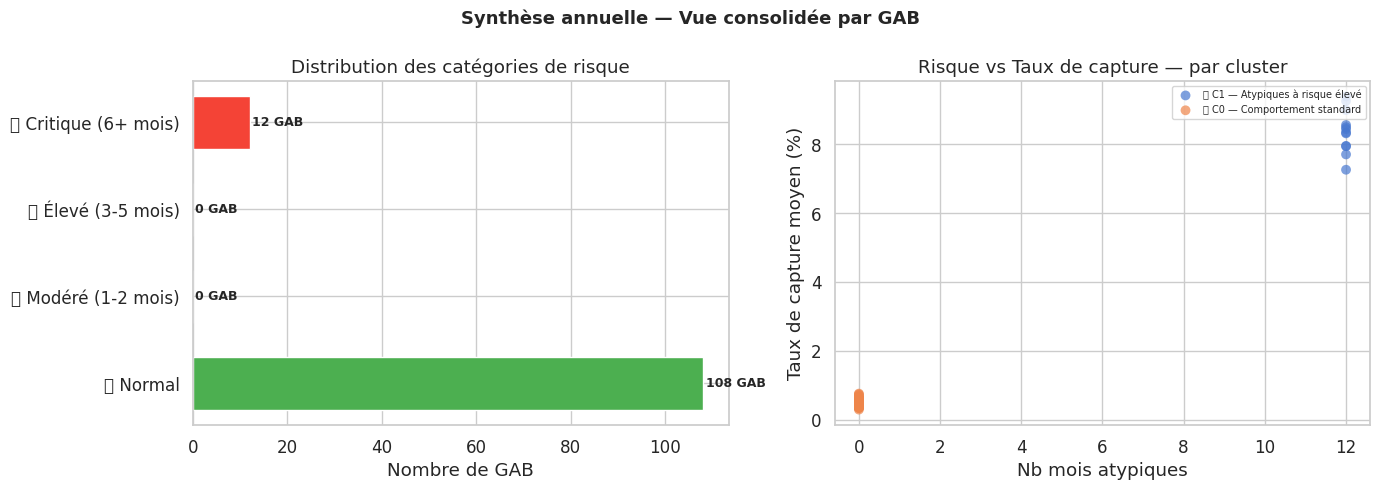

In [28]:
# ── 9bis.4 Graphique synthèse annuelle ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Synthèse annuelle — Vue consolidée par GAB', fontsize=13, fontweight='bold')

# Gauche : distribution des catégories de risque
ax1 = axes[0]
cat_counts = df_annuel['categorie_risque'].value_counts().sort_index()
bar_colors  = ['#4CAF50', '#FFC107', '#FF9800', '#F44336'][:len(cat_counts)]
bars = ax1.barh(cat_counts.index.astype(str), cat_counts.values,
                color=bar_colors, edgecolor='white', height=0.6)
ax1.set_title('Distribution des catégories de risque')
ax1.set_xlabel('Nombre de GAB')
for bar, val in zip(bars, cat_counts.values):
    ax1.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
             f'{val} GAB', va='center', fontsize=9, fontweight='bold')

# Droite : scatter nb_mois_atypiques vs taux_capture coloré par cluster
ax2 = axes[1]
for cid in sorted(df_annuel['cluster_nom'].unique()):
    mask = df_annuel['cluster_nom'] == cid
    cid_num = df_annuel.loc[mask,'cluster_nom'].index[0] % len(PALETTE_CLUSTERS)
    ax2.scatter(df_annuel.loc[mask,'nb_mois_atypiques'],
                df_annuel.loc[mask,'taux_capture_moyen'],
                label=cid, alpha=0.7, s=50, edgecolors='none')
ax2.set_xlabel('Nb mois atypiques')
ax2.set_ylabel('Taux de capture moyen (%)')
ax2.set_title('Risque vs Taux de capture — par cluster')
ax2.legend(fontsize=7, loc='upper right', framealpha=0.8)

plt.tight_layout()
plt.savefig('synthese_annuelle.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. ✅ Validation du Modèle

### Comment évaluer un modèle sans étiquettes ?

Sans vérité terrain, nous utilisons 3 méthodes de validation alternatives :

1. **Validation statistique** : les anomalies détectées sont-elles vraiment aux extrêmes des distributions ?
2. **Analyse des cas extrêmes** : les GAB avec z-score > 3 sont-ils bien détectés ?
3. **Plausibilité métier** : les explications correspondent-elles à des situations connues ?

In [29]:
# ── 10.1 Validation statistique ───────────────────────────────────────────────
print('📊 Comparaison statistique : Normaux vs Atypiques')
print('=' * 65)

stats_comp = df.groupby('est_anomalie')[[
    'ret_nb','ret_montant_moyen','taux_capture_pct','ret_pct_nuit'
]].mean().round(2)

stats_comp.index = ['🟢 Normaux', '🔴 Atypiques']
stats_comp.columns = ['Nb retraits', 'Montant moyen (€)', 'Taux capture (%)', '% Nuit']

print(stats_comp.to_string())
print()

# Ratios
ratios = (stats_comp.loc['🔴 Atypiques'] / stats_comp.loc['🟢 Normaux']).round(2)
print('📈 Ratios Atypiques / Normaux :')
for col, ratio in ratios.items():
    indicateur = '🔴 Anormal' if ratio > 1.5 or ratio < 0.5 else '🟡 Notable' if ratio > 1.2 else '🟢 Proche'
    print(f'   {indicateur}  {col} : ×{ratio}')

📊 Comparaison statistique : Normaux vs Atypiques
             Nb retraits  Montant moyen (€)  Taux capture (%)  % Nuit
🟢 Normaux         867.83             164.63              0.90   11.22
🔴 Atypiques      2079.19             419.39              8.87   34.22

📈 Ratios Atypiques / Normaux :
   🔴 Anormal  Nb retraits : ×2.4
   🔴 Anormal  Montant moyen (€) : ×2.55
   🔴 Anormal  Taux capture (%) : ×9.86
   🔴 Anormal  % Nuit : ×3.05


In [30]:
# ── 10.2 Validation par z-scores (règle des 3σ) ───────────────────────────────
cols_zscore = ['ret_nb','ret_montant_moyen','taux_capture_pct','ret_pct_nuit']

for col in cols_zscore:
    mu  = df[col].mean()
    sig = df[col].std()
    df[f'zscore_{col}'] = (df[col] - mu) / (sig + 1e-9)

df['nb_zscore_extreme'] = sum(
    (df[f'zscore_{c}'].abs() > 3).astype(int) for c in cols_zscore
)

# Taux de détection croisée
detectes_zscore    = df[df['nb_zscore_extreme'] >= 1]['est_anomalie'].mean()
non_detectes_model = df[(df['est_anomalie']==1) & (df['nb_zscore_extreme']==0)].shape[0]

print(f'🔬 Validation croisée :')
print(f'   → {detectes_zscore*100:.1f}% des cas extrêmes (z>3) sont classés atypiques par le modèle')
print(f'   → {non_detectes_model} anomalies détectées par le modèle MAIS non visibles par z-score simple')
print(f'     (→ ce sont les anomalies subtiles, invisibles à l\'œil nu 🎯)')

🔬 Validation croisée :
   → 52.1% des cas extrêmes (z>3) sont classés atypiques par le modèle
   → 9 anomalies détectées par le modèle MAIS non visibles par z-score simple
     (→ ce sont les anomalies subtiles, invisibles à l'œil nu 🎯)


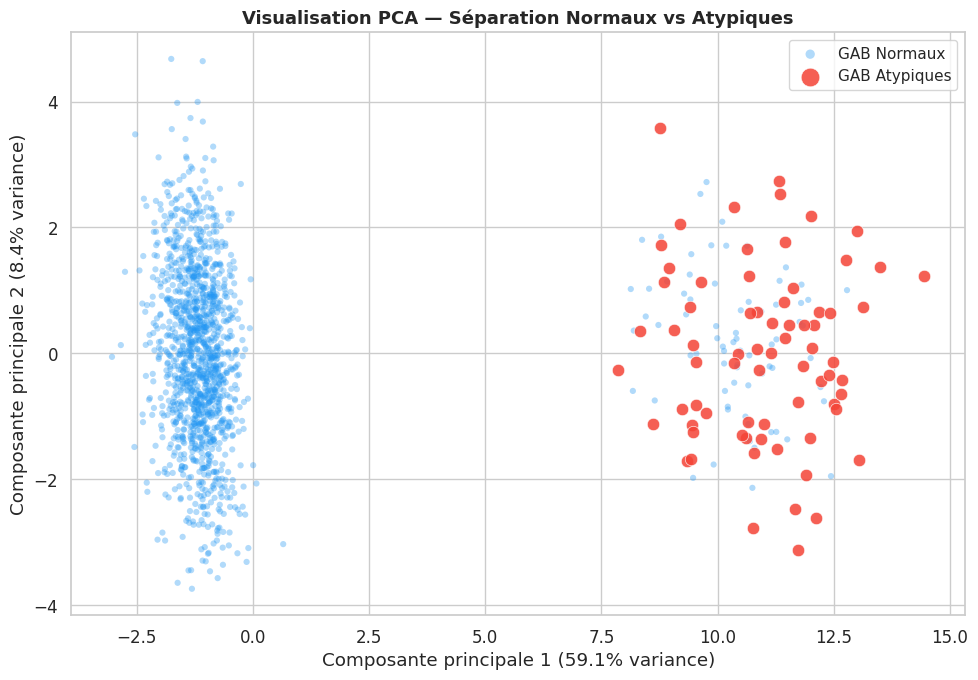

💡 Les points rouges (atypiques) se situent bien aux marges du nuage principal → validation visuelle.


In [31]:
# ── 10.3 Réduction dimensionnelle PCA pour visualisation ──────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df['pca1'] = X_pca[:, 0]
df['pca2'] = X_pca[:, 1]

fig, ax = plt.subplots(figsize=(10, 7))

for label, mask, couleur, taille, alpha in [
    ('GAB Normaux',   df['est_anomalie']==0, COULEUR_NORMAL,   20, 0.35),
    ('GAB Atypiques', df['est_anomalie']==1, COULEUR_ANOMALIE, 80, 0.85),
]:
    ax.scatter(df[mask]['pca1'], df[mask]['pca2'],
               c=couleur, s=taille, alpha=alpha, label=label,
               edgecolors='white' if taille > 30 else 'none', linewidths=0.5)

ax.set_xlabel(f'Composante principale 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'Composante principale 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('Visualisation PCA — Séparation Normaux vs Atypiques', fontsize=13, fontweight='bold')
ax.legend(markerscale=1.5, fontsize=11)

plt.tight_layout()
plt.savefig('pca_anomalies.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Les points rouges (atypiques) se situent bien aux marges du nuage principal → validation visuelle.')

## 11. 📖 Synthèse — Ce que le Modèle a Découvert

### Conclusions pour les équipes métier

In [32]:
# ── 11.1 Tableau de bord synthèse ─────────────────────────────────────────────
n_total     = len(df)
n_anom      = df['est_anomalie'].sum()
n_normal_d  = n_total - n_anom
score_moy   = df[df['est_anomalie']==1]['score_risque'].mean()

print('=' * 60)
print('  📋 SYNTHÈSE — DÉTECTION D\'ANOMALIES GAB')
print('=' * 60)
print(f'  🏧 Total automates analysés      : {n_total}')
print(f'  🟢 GAB au comportement normal    : {n_normal_d} ({n_normal_d/n_total*100:.1f}%)')
print(f'  🔴 GAB au comportement atypique  : {n_anom} ({n_anom/n_total*100:.1f}%)')
print(f'  📊 Score de risque moyen (atyp.) : {score_moy:.3f} / 1.000')
print('=' * 60)
print()
print('  COMPORTEMENT NORMAL DU RÉSEAU :')
normaux = df[df['est_anomalie']==0]
print(f'  • Volume moyen      : {normaux["ret_nb"].mean():.0f} retraits/mois')
print(f'  • Montant moyen     : {normaux["ret_montant_moyen"].mean():.0f} €')
print(f'  • Taux capture moy. : {normaux["taux_capture_pct"].mean():.2f}%')
print(f'  • Activité nocturne : {normaux["ret_pct_nuit"].mean():.1f}%')
print()
print('  SIGNAUX D\'ALERTE LES PLUS FRÉQUENTS :')
print('  🔴 Taux de capture anormalement élevé (fraude / panne)')
print('  🔴 Montants moyens hors norme (opérations inhabituelles)')
print('  🔴 Activité nocturne excessive (comportement suspect)')
print('  🔴 Concentration réseau atypique (anomalie de flux cartes)')
print('=' * 60)

  📋 SYNTHÈSE — DÉTECTION D'ANOMALIES GAB
  🏧 Total automates analysés      : 1440
  🟢 GAB au comportement normal    : 1368 (95.0%)
  🔴 GAB au comportement atypique  : 72 (5.0%)
  📊 Score de risque moyen (atyp.) : 0.867 / 1.000

  COMPORTEMENT NORMAL DU RÉSEAU :
  • Volume moyen      : 868 retraits/mois
  • Montant moyen     : 165 €
  • Taux capture moy. : 0.90%
  • Activité nocturne : 11.2%

  SIGNAUX D'ALERTE LES PLUS FRÉQUENTS :
  🔴 Taux de capture anormalement élevé (fraude / panne)
  🔴 Montants moyens hors norme (opérations inhabituelles)
  🔴 Activité nocturne excessive (comportement suspect)
  🔴 Concentration réseau atypique (anomalie de flux cartes)


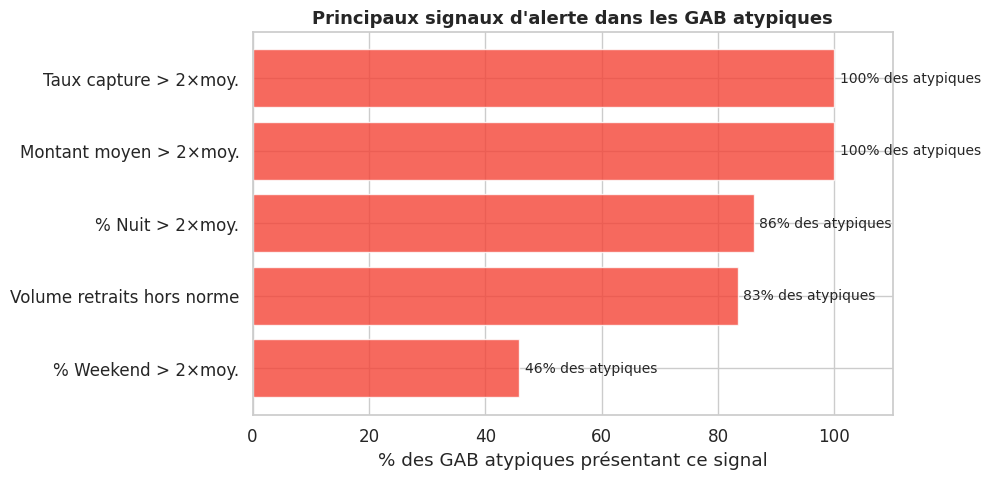

In [33]:
# ── 11.2 Graphique final : les signaux d'alerte par fréquence ─────────────────
anom_df = df[df['est_anomalie']==1]
norm_df = df[df['est_anomalie']==0]

signaux = {
    'Taux capture > 2×moy.':       (anom_df['taux_capture_pct']   > norm_df['taux_capture_pct'].mean()*2).mean()*100,
    'Montant moyen > 2×moy.':      (anom_df['ret_montant_moyen']  > norm_df['ret_montant_moyen'].mean()*2).mean()*100,
    '% Nuit > 2×moy.':             (anom_df['ret_pct_nuit']       > norm_df['ret_pct_nuit'].mean()*2).mean()*100,
    '% Weekend > 2×moy.':          (anom_df['ret_pct_weekend']    > norm_df['ret_pct_weekend'].mean()*2).mean()*100,
    'Volume retraits hors norme':   (anom_df['ret_nb'].abs()       > norm_df['ret_nb'].mean()*2).mean()*100,
}

signaux_series = pd.Series(signaux).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(signaux_series.index, signaux_series.values,
               color=COULEUR_ANOMALIE, alpha=0.8, edgecolor='white')

for bar, val in zip(bars, signaux_series.values):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}% des atypiques', va='center', fontsize=10)

ax.set_xlabel('% des GAB atypiques présentant ce signal')
ax.set_title('Principaux signaux d\'alerte dans les GAB atypiques', fontsize=13, fontweight='bold')
ax.set_xlim(0, 110)
plt.tight_layout()
plt.savefig('signaux_alerte.png', dpi=150, bbox_inches='tight')
plt.show()

In [34]:
# ── 11.3 Export de la liste des GAB à investiguer ─────────────────────────────
liste_investigation = df[df['est_anomalie']==1][
    ['num_automate','score_risque','ret_nb','ret_montant_moyen',
     'taux_capture_pct','ret_pct_nuit','ret_pct_weekend','type_gab_e_i','code_postal']
].sort_values('score_risque', ascending=False).reset_index(drop=True)

liste_investigation.index += 1

# Décommenter pour exporter
# liste_investigation.to_csv('gab_a_investiguer.csv', index=True)
# print('✅ Fichier exporté : gab_a_investiguer.csv')

print(f'📋 {len(liste_investigation)} GAB recommandés pour investigation :')
display(liste_investigation.head(15).style
    .background_gradient(subset=['score_risque'], cmap='Reds')
    .format({'score_risque': '{:.3f}', 'taux_capture_pct': '{:.2f}',
             'ret_montant_moyen': '{:.0f}'}))

📋 72 GAB recommandés pour investigation :


,num_automate,score_risque,ret_nb,ret_montant_moyen,taux_capture_pct,ret_pct_nuit,ret_pct_weekend,type_gab_e_i,code_postal
1,GAB_0119,1.000,2584,462,12.37,41.700905,49.598718,Externe,59000
2,GAB_0114,0.966,1635,454,10.63,23.165012,34.431054,Interne,75001
3,GAB_0114,0.955,2595,350,8.70,41.060393,31.383547,Interne,75001
4,GAB_0111,0.955,2615,453,9.51,47.320332,47.222101,Interne,59000
5,GAB_0118,0.946,1904,431,14.96,22.445472,28.724589,Externe,75001
6,GAB_0112,0.941,1930,418,14.66,35.738670,59.303775,Externe,69001
7,GAB_0117,0.930,2116,392,10.87,39.311396,50.228600,Interne,69001
8,GAB_0110,0.921,1834,406,11.65,50.446957,50.027893,Interne,59000
9,GAB_0113,0.920,2883,452,9.44,25.924532,57.218129,Interne,33000
10,GAB_0111,0.919,2357,451,9.99,20.509083,54.910934,Externe,59000


## 12. 📌 Conclusion & Recommandations

---

### Ce que le modèle apporte

| Ce que vous faisiez avant | Ce que le modèle permet maintenant |
|---|---|
| Surveillance manuelle par seuil | Détection automatique multi-dimensionnelle |
| Anomalies évidentes seulement | Détection de signaux faibles combinés |
| Analyse rétrospective | Alerte mensuelle systématique |
| Subjectif / expertise individuelle | Reproductible et documenté |

---

### Prochaines étapes recommandées

1. **Validation métier** : soumettre la liste des GAB détectés aux experts pour qualification (vrai/faux positif)
2. **Enrichissement** : intégrer des données de contexte (incidents déclarés, interventions techniques)
3. **Mise en production** : exécution mensuelle automatique dans Dataiku
4. **Amélioration continue** : avec les retours métier, passer progressivement à un modèle semi-supervisé

---

> *« Un modèle n'est pas là pour remplacer l'expertise métier, mais pour l'amplifier.  
> Il voit ce que l'œil ne peut pas voir sur 500 automates simultanément. »*

---